In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe
from matplotlib.colors import to_rgba
import pandas as pd
from lfp.lfp_analysis.LFP_collection import LFPCollection

# ── 1. COLORS AND LAYOUT ─────────────────────────────────────────────────────

agent_colors = {
    "cagemate": "#792910",
    "familiar": "#FFAF00",
    "novel":    "#15616F"
}

regions    = ["mPFC", "NAc", "MD", "BLA", "vHPC"]
bands      = ["Delta", "Theta", "Beta", "Low gamma", "High gamma"]
band_short = ["D", "T", "B", "LG", "HG"]

# Region positions around the circle (in degrees, evenly spaced)
n_regions  = len(regions)
region_angles = {r: 90 - i * (360 / n_regions) for i, r in enumerate(regions)}

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
cups_lfp_json = r"C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\Cups (phase 4)\lfp_data_updated\lfp_collection.json"

cups_collection = LFPCollection.load_collection(cups_lfp_json)

In [ ]:
def plot_heatmap(lfp_collection, events, freq, color, vmax=None, vmin = None, baselines=None, event_len=None,mode = 'granger'):
    """
    Plot Granger causality heatmaps for multiple events as subplots with a shared colorbar per row.
    
    Parameters:
    -----------
    lfp_collection : LFP collection object
    events : list of strings, event names to plot
    freq : tuple, frequency range (min_freq, max_freq)
    color : list of two colors for colormap gradient
    vmax : float, maximum value for colorbar (applied to all plots)
    baselines : optional, list of baseline events corresponding to each event or single baseline for all
    event_len : optional, event length to analyze
    """
    from matplotlib.gridspec import GridSpec
    import numpy as np
    
    # Handle baselines parameter
    if baselines is None:
        # No baselines specified, use None for all events
        event_baselines = [None] * len(events)
    elif isinstance(baselines, list) and len(baselines) == len(events):
        # List of baselines matching events
        event_baselines = baselines
    else:
        # Single baseline for all events
        event_baselines = [baselines] * len(events)
    
    # Calculate Granger causality for each event with its corresponding baseline
    event_grangers = {}
    for event, baseline in zip(events, event_baselines):
        event_data = ee.average_events(
            lfp_collection, [event], mode=mode, 
            baseline=baseline, event_len=event_len, plot=False
        )
        print(len(event_data[event]))
        print(event_data[event][0].shape)
        event_grangers[event] = event_data[event]
    
    n_events = len(events)
    n_cols = min(3, n_events)  # Max 3 columns
    n_rows = (n_events + n_cols - 1) // n_cols  # Ceiling division
    
    # Create custom grid to accommodate colorbars
    fig = plt.figure(figsize=(5 * n_cols + 0.5, 4 * n_rows))
    gs = GridSpec(n_rows, n_cols + 1, width_ratios=[1] * n_cols + [0.05])
    
    # Get brain regions once since they're the same for all plots
    brain_regions = np.empty(len(lfp_collection.brain_region_dict.keys()), dtype="<U10")
    for i in range(len(lfp_collection.brain_region_dict.keys())):
        brain_regions[i] = lfp_collection.brain_region_dict.inverse[i]
    
    # Create custom colormap
    cmap = LinearSegmentedColormap.from_list('custom', color, N=100)
    
    # Calculate global vmax if not provided
    if vmax is None:
        all_values = []
        for event in events:
            event_granger = event_grangers[event]
            print(event_granger[event].shape)
            avg_granger = np.nanmean(event_granger, axis=0)
            freq_granger = avg_granger[freq[0]:freq[1], :, :]
            avg_freq = np.nanmean(freq_granger, axis=0)
            all_values.append(np.nanmax(avg_freq))
        vmax = np.max(all_values)
    if vmin is None:
        all_values = []
        for event in events:
            event_granger = event_grangers[event]
            avg_granger = np.nanmean(event_granger, axis=0)
            freq_granger = avg_granger[freq[0]:freq[1], :, :]
            avg_freq = np.nanmean(freq_granger, axis=0)
            all_values.append(np.nanmin(avg_freq))
        vmin = np.min(all_values)
    # Get all data matrices for consistent color scaling
    data_matrices = []
    for event in events:
        event_granger = event_grangers[event]
        avg_granger = np.nanmean(event_granger, axis=0)
        freq_granger = avg_granger[freq[0]:freq[1], :, :]
        avg_freq = np.nanmean(freq_granger, axis=0)
        data_matrices.append(avg_freq)
    
    # Plot each event
    axes = []
    for idx, event in enumerate(events):
        row = idx // n_cols
        col = idx % n_cols
        
        # Create subplot
        ax = fig.add_subplot(gs[row, col])
        axes.append(ax)
        
        # Get data
        avg_freq = data_matrices[idx]
        
        # Create heatmap without colorbar
        sns.heatmap(avg_freq, xticklabels=brain_regions, yticklabels=brain_regions,
                   annot=True, cmap=cmap, ax=ax, vmax=vmax, vmin=vmin, cbar=False)
        
        # Add baseline information to title if available
        baseline_info = ""
        if event_baselines[idx] is not None:
            baseline_info = f"\nBaseline: {event_baselines[idx]}"
            
        ax.set_title(f"{event} Granger Causality\n{freq[0]}Hz to {freq[1]}Hz{baseline_info}")
        
        # Rotate labels for better readability
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        ax.set_ylabel("From")
        ax.set_xlabel("To")
        
        # Add colorbar at the end of each row
        if col == n_cols - 1 or idx == len(events) - 1:
            cbar_ax = fig.add_subplot(gs[row, -1])
            plt.colorbar(ax.collections[0], cax=cbar_ax)
    
    # Add overall title
    plt.suptitle(f"Granger Causality Analysis ({freq[0]}-{freq[1]}Hz)", 
                fontsize=16, y=1.02)
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

In [ ]:
plot_heatmap(cups_collection, events =['familiar'], baselines = ['familiar_baseline'], freq = (4,13), color = ['white','#792910'] , vmax = 15, mode = 'power')

10
(500, 5)


c:\Users\megha\Documents\GitHub\diff_fam_social_memory_ephys\lfp\lfp_analysis\event_extraction.py:115: RuntimeWarning: Mean of empty slice
  event_snippet = np.nanmean(event_snippet, axis=0)
c:\Users\megha\Documents\GitHub\diff_fam_social_memory_ephys\lfp\lfp_analysis\event_extraction.py:182: RuntimeWarning: Mean of empty slice
  baseline_recording = np.nanmean(np.array(baseline_averages), axis=0)
c:\Users\megha\Documents\GitHub\diff_fam_social_memory_ephys\lfp\lfp_analysis\event_extraction.py:227: RuntimeWarning: Mean of empty slice
  rec_event_average = np.nanmean(np.array(adj_averages), axis = 0)


IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

<Figure size 550x400 with 0 Axes>

c:\Users\megha\Documents\GitHub\diff_fam_social_memory_ephys\lfp\lfp_analysis\event_extraction.py:115: RuntimeWarning: Mean of empty slice
  event_snippet = np.nanmean(event_snippet, axis=0)
c:\Users\megha\Documents\GitHub\diff_fam_social_memory_ephys\lfp\lfp_analysis\event_extraction.py:182: RuntimeWarning: Mean of empty slice
  baseline_recording = np.nanmean(np.array(baseline_averages), axis=0)
c:\Users\megha\Documents\GitHub\diff_fam_social_memory_ephys\lfp\lfp_analysis\event_extraction.py:227: RuntimeWarning: Mean of empty slice
  rec_event_average = np.nanmean(np.array(adj_averages), axis = 0)


10
(500, 5, 5)


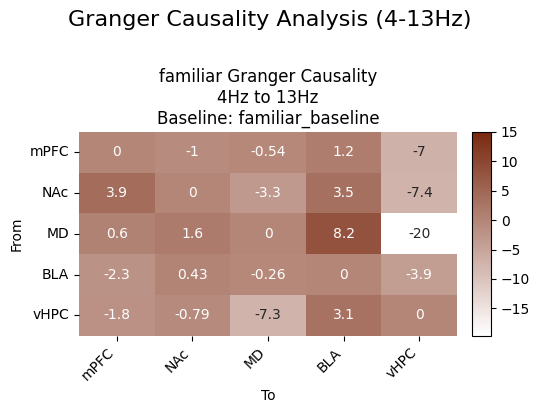

In [ ]:
plot_heatmap(cups_collection, events =['familiar'], baselines = ['familiar_baseline'], freq = (4,13), color = ['white','#792910'] , vmax = 15, mode = 'granger')

c:\Users\megha\Documents\GitHub\diff_fam_social_memory_ephys\lfp\lfp_analysis\event_extraction.py:115: RuntimeWarning: Mean of empty slice
  event_snippet = np.nanmean(event_snippet, axis=0)
c:\Users\megha\Documents\GitHub\diff_fam_social_memory_ephys\lfp\lfp_analysis\event_extraction.py:182: RuntimeWarning: Mean of empty slice
  baseline_recording = np.nanmean(np.array(baseline_averages), axis=0)
c:\Users\megha\Documents\GitHub\diff_fam_social_memory_ephys\lfp\lfp_analysis\event_extraction.py:227: RuntimeWarning: Mean of empty slice
  rec_event_average = np.nanmean(np.array(adj_averages), axis = 0)


10
(500, 5, 5)


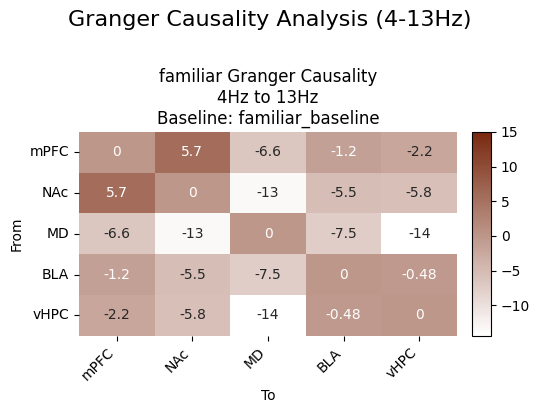

In [ ]:
plot_heatmap(cups_collection, events =['familiar'], baselines = ['familiar_baseline'], freq = (4,13), color = ['white','#792910'] , vmax = 15, mode = 'coherence')

In [ ]:
%pwd

'c:\\Users\\megha\\Documents\\GitHub\\diff_fam_social_memory_ephys'

Sig power band-specific:
    region        band
0    mPFC       Delta
9    mPFC   Low gamma
12   mPFC  High gamma
21    NAc        Beta
26    NAc   Low gamma
27    NAc  High gamma
30     MD       Delta
36     MD        Beta
39     MD   Low gamma
42     MD  High gamma
45    BLA       Delta
50    BLA       Theta
57    BLA  High gamma

Sig power main effect:
    region
60   vHPC

Sig coherence pairs:
         pair        band
27   mPFC_MD  High gamma
30  mPFC_BLA       Delta
58    NAc_MD  High gamma
67   NAc_BLA        Beta
71   NAc_BLA   Low gamma
86    MD_BLA        Beta
91    MD_BLA  High gamma


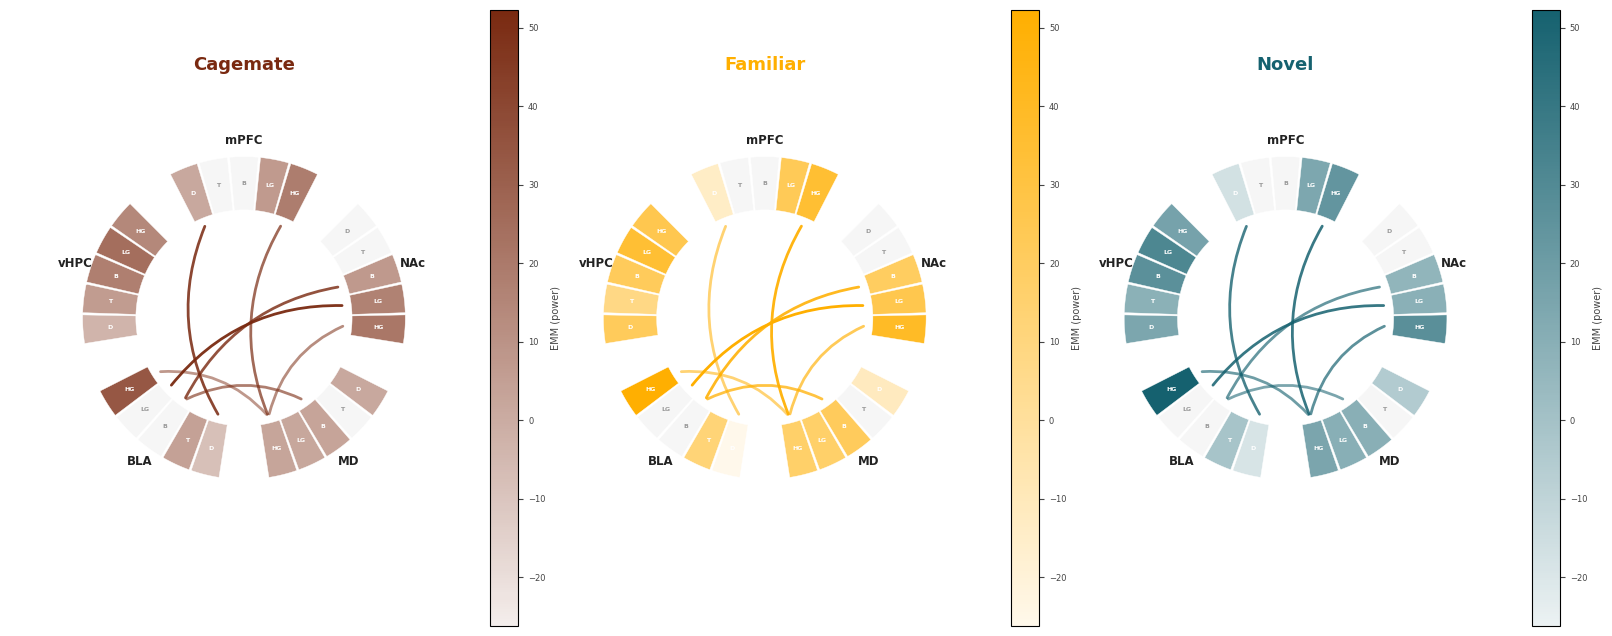

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import to_rgba, Normalize, LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec
import pandas as pd

# ── COLORS AND LAYOUT ─────────────────────────────────────────────────────────

agent_colors = {
    "cagemate": "#792910",
    "familiar": "#FFAF00",
    "novel":    "#15616F"
}

regions    = ["mPFC", "NAc", "MD", "BLA", "vHPC"]
bands      = ["Delta", "Theta", "Beta", "Low gamma", "High gamma"]
band_short = ["D", "T", "B", "LG", "HG"]

# ── LOAD DATA ─────────────────────────────────────────────────────────────────

power_emm           = pd.read_csv("pilot2/cups_phase4/r_stuff/power_emm.csv")
coherence_emm       = pd.read_csv("pilot2/cups_phase4/r_stuff/coherence_emm.csv")
power_contrasts     = pd.read_csv("pilot2/cups_phase4/r_stuff/power_contrasts.csv")
coherence_contrasts = pd.read_csv("pilot2/cups_phase4/r_stuff/coherence_contrasts.csv")

# ── FIX CAPITALIZATION ────────────────────────────────────────────────────────

name_fix = {"mPFC_Nac": "mPFC_NAc"}
coherence_emm["region"]       = coherence_emm["region"].replace(name_fix)
coherence_contrasts["region"] = coherence_contrasts["region"].replace(name_fix)

# ── SIGNIFICANT CELLS — NaN-safe ──────────────────────────────────────────────

REAL_SIG = ["*", "**", "***"]

def is_real_sig(series):
    return series.notna() & series.isin(REAL_SIG)

# Band-specific power significance: region × band
sig_power_band = (
    power_contrasts[
        is_real_sig(power_contrasts["sig"]) &
        power_contrasts["band"].notna()
    ]
    .drop_duplicates(subset=["region", "band"])
    [["region", "band"]]
    .copy()
)

# Main effect power significance: whole region lights up (all bands)
sig_power_main = (
    power_contrasts[
        is_real_sig(power_contrasts["sig"]) &
        power_contrasts["plot_type"].str.contains("main_effect", na=False)
    ]
    .drop_duplicates(subset=["region"])
    [["region"]]
    .copy()
)

# Coherence: pair × band
sig_coherence_pairs = (
    coherence_contrasts[
        is_real_sig(coherence_contrasts["sig"]) &
        coherence_contrasts["band"].notna()
    ]
    .rename(columns={"region": "pair"})
    .drop_duplicates(subset=["pair", "band"])
    [["pair", "band"]]
    .copy()
)

print("Sig power band-specific:\n",   sig_power_band)
print("\nSig power main effect:\n",    sig_power_main)
print("\nSig coherence pairs:\n",      sig_coherence_pairs)

# ── VALID COHERENCE PAIRS ─────────────────────────────────────────────────────

valid_coherence_pairs = coherence_emm["region"].unique().tolist()

# ── NORMALIZE EMMEANS ─────────────────────────────────────────────────────────

power_global_min     = power_emm["emmean"].min()
power_global_max     = power_emm["emmean"].max()
coherence_global_min = coherence_emm["emmean"].min()
coherence_global_max = coherence_emm["emmean"].max()

def emmean_to_opacity(value, vmin, vmax, min_alpha=0.08, max_alpha=1.0):
    if vmax == vmin:
        return min_alpha
    scaled = (value - vmin) / (vmax - vmin)
    return float(np.clip(scaled, 0, 1) * (max_alpha - min_alpha) + min_alpha)

# ── GEOMETRY ──────────────────────────────────────────────────────────────────

region_span_deg = 55.0
gap_deg         = (360.0 - region_span_deg * len(regions)) / len(regions)
band_span_deg   = region_span_deg / len(bands)

region_center_angles = {}
start = 90.0
for i, r in enumerate(regions):
    region_center_angles[r] = start - i * (region_span_deg + gap_deg)

def band_center_deg(region, band_idx):
    rc    = region_center_angles[region]
    start = rc + region_span_deg / 2.0
    return start - (band_idx + 0.5) * band_span_deg

def deg2rad(d):
    return np.pi * d / 180.0

def arc_polygon(center_deg, half_deg, r_inner, r_outer, n=60):
    a0     = deg2rad(center_deg - half_deg)
    a1     = deg2rad(center_deg + half_deg)
    angles = np.linspace(a0, a1, n)
    xs = np.concatenate([r_outer * np.cos(angles),
                         r_inner * np.cos(angles[::-1])])
    ys = np.concatenate([r_outer * np.sin(angles),
                         r_inner * np.sin(angles[::-1])])
    return xs, ys

def chord_endpoint(region, band_idx, r=0.62):
    angle = deg2rad(band_center_deg(region, band_idx))
    return r * np.cos(angle), r * np.sin(angle)

def parse_pair(pair_name):
    if pair_name not in valid_coherence_pairs:
        return None, None
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

def is_sig_power(region, band):
    """True if this region×band should be highlighted —
    either band-specific significance OR whole-region main effect."""
    band_sig = (
        (sig_power_band["region"] == region) &
        (sig_power_band["band"]   == band)
    ).any()
    main_sig = (sig_power_main["region"] == region).any()
    return bool(band_sig or main_sig)

# ── PLOT FUNCTION ─────────────────────────────────────────────────────────────

def plot_connectogram(ax, cbar_ax, agent, agent_color):

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_title(agent.capitalize(),
                 color=agent_color, fontsize=13,
                 fontweight="bold", pad=10)

    r_inner = 0.67
    r_outer = 1.00
    half    = band_span_deg / 2.0 - 0.4

    # ── Power arcs ────────────────────────────────────────────────────────────
    for region in regions:
        for bi, (band, bs) in enumerate(zip(bands, band_short)):

            center = band_center_deg(region, bi)
            is_sig = is_sig_power(region, band)

            row = power_emm[
                (power_emm["agent"]  == agent) &
                (power_emm["region"] == region) &
                (power_emm["band"]   == band)
            ]

            if len(row) > 0 and is_sig:
                alpha = emmean_to_opacity(
                    row["emmean"].values[0],
                    power_global_min, power_global_max
                )
                color = agent_color
            else:
                alpha = 0.12
                color = "#BBBBBB"

            xs, ys = arc_polygon(center, half, r_inner, r_outer)
            ax.fill(xs, ys, color=color, alpha=alpha,
                    linewidth=0, zorder=2)
            ax.plot(np.append(xs, xs[0]),
                    np.append(ys, ys[0]),
                    color="white", lw=0.3, zorder=3)

            label_r = (r_inner + r_outer) / 2.0
            label_a = deg2rad(center)
            ax.text(label_r * np.cos(label_a),
                    label_r * np.sin(label_a),
                    bs, ha="center", va="center",
                    fontsize=4.5,
                    color="white" if is_sig else "#999999",
                    fontweight="bold", zorder=4)

        # Region label
        label_r = r_outer + 0.10
        label_a = deg2rad(region_center_angles[region])
        ax.text(label_r * np.cos(label_a),
                label_r * np.sin(label_a),
                region, ha="center", va="center",
                fontsize=8.5, fontweight="bold",
                color="#222222", zorder=4)

    # ── Coherence chords ──────────────────────────────────────────────────────
    plotted = set()

    for _, sig_row in sig_coherence_pairs.iterrows():
        pair = sig_row["pair"]
        band = sig_row["band"]

        if band not in bands:
            continue
        bi = bands.index(band)

        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            continue

        key = (tuple(sorted([r1, r2])), band)
        if key in plotted:
            continue
        plotted.add(key)

        emm_row = coherence_emm[
            (coherence_emm["agent"]  == agent) &
            (coherence_emm["region"] == pair)  &
            (coherence_emm["band"]   == band)
        ]
        if len(emm_row) == 0:
            pair_rev = f"{r2}_{r1}"
            emm_row  = coherence_emm[
                (coherence_emm["agent"]  == agent) &
                (coherence_emm["region"] == pair_rev) &
                (coherence_emm["band"]   == band)
            ]

        alpha = (
            emmean_to_opacity(
                emm_row["emmean"].values[0],
                coherence_global_min, coherence_global_max,
                min_alpha=0.15
            )
            if len(emm_row) > 0 else 0.25
        )

        x1, y1 = chord_endpoint(r1, bi, r=0.63)
        x2, y2 = chord_endpoint(r2, bi, r=0.63)

        ax.annotate("",
            xy      =(x2, y2), xycoords="data",
            xytext  =(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle      = "-",
                color           = to_rgba(agent_color, alpha),
                lw              = 2.0,
                connectionstyle = "arc3,rad=0.25"
            ),
            zorder=1
        )

    # ── Colorbar ──────────────────────────────────────────────────────────────
    base_rgb   = mcolors.to_rgb(agent_color)
    cmap_agent = LinearSegmentedColormap.from_list(
        f"cmap_{agent}",
        [(*base_rgb, 0.08), (*base_rgb, 1.00)]
    )
    norm = Normalize(vmin=power_global_min, vmax=power_global_max)
    cb   = ColorbarBase(cbar_ax, cmap=cmap_agent, norm=norm,
                        orientation="vertical")
    cb.set_label("EMM (power)", fontsize=7, color="#444444")
    cb.ax.tick_params(labelsize=6, colors="#444444")

# ── RENDER ────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 8), facecolor="white")
gs  = GridSpec(1, 6,
               width_ratios=[1, 0.06, 1, 0.06, 1, 0.06],
               wspace=0.05)

axes_main = [fig.add_subplot(gs[0, i * 2])     for i in range(3)]
axes_cbar = [fig.add_subplot(gs[0, i * 2 + 1]) for i in range(3)]

for ax, cbar_ax, agent in zip(axes_main, axes_cbar,
                               ["cagemate", "familiar", "novel"]):
    plot_connectogram(
        ax          = ax,
        cbar_ax     = cbar_ax,
        agent       = agent,
        agent_color = agent_colors[agent]
    )

plt.savefig("connectogram_all_agents.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
# ── DEBUG: trace exactly what's being plotted ─────────────────────────────────

print("=== sig_coherence_pairs ===")
print(sig_coherence_pairs)

print("\n=== valid_coherence_pairs ===")
print(valid_coherence_pairs)

print("\n=== All unique regions in coherence_contrasts ===")
print(coherence_contrasts["region"].unique())

print("\n=== All rows in coherence_contrasts where region contains 'NAc' ===")
print(coherence_contrasts[coherence_contrasts["region"].str.contains("NAc", na=False)][["region", "band", "sig"]].drop_duplicates())

print("\n=== sig_coherence_pairs after filtering sig != '' ===")
print(coherence_contrasts[coherence_contrasts["sig"] != ""][["region", "band", "sig"]].drop_duplicates())

=== sig_coherence_pairs ===
        pair        band
27   mPFC_MD  High gamma
30  mPFC_BLA       Delta
58    NAc_MD  High gamma
67   NAc_BLA        Beta
71   NAc_BLA   Low gamma
86    MD_BLA        Beta
91    MD_BLA  High gamma

=== valid_coherence_pairs ===
['mPFC_NAc', 'mPFC_MD', 'mPFC_BLA', 'NAc_MD', 'NAc_BLA', 'NAc_vHPC', 'MD_BLA', 'BLA_vHPC', 'MD_vHPC']

=== All unique regions in coherence_contrasts ===
['mPFC_NAc' 'mPFC_MD' 'mPFC_BLA' 'NAc_MD' 'NAc_BLA' 'NAc_vHPC' 'MD_BLA']

=== All rows in coherence_contrasts where region contains 'NAc' ===
      region        band  sig
0   mPFC_NAc       Delta  NaN
3   mPFC_NAc       Theta  NaN
6   mPFC_NAc        Beta  NaN
9   mPFC_NAc   Low gamma  NaN
12  mPFC_NAc  High gamma  NaN
45    NAc_MD       Delta  NaN
48    NAc_MD       Theta  NaN
51    NAc_MD        Beta  NaN
54    NAc_MD   Low gamma  NaN
57    NAc_MD  High gamma  NaN
58    NAc_MD  High gamma   **
60   NAc_BLA       Delta  NaN
63   NAc_BLA       Theta  NaN
66   NAc_BLA        Beta  

In [ ]:
# ── SAFE significant cell filtering ──────────────────────────────────────────

sig_power_cells = (
    power_contrasts[
        power_contrasts["sig"].notna() &           # drop NaN
        power_contrasts["sig"].isin(["*", "**", "***"])  # only real sig
    ]
    .drop_duplicates(subset=["region", "band"])
    [["region", "band"]]
    .copy()
)

sig_coherence_pairs = (
    coherence_contrasts[
        coherence_contrasts["sig"].notna() &
        coherence_contrasts["sig"].isin(["*", "**", "***"])
    ]
    .rename(columns={"region": "pair"})
    .drop_duplicates(subset=["pair", "band"])
    [["pair", "band"]]
    .copy()
)

sig_granger_pairs = (
    granger_contrasts[
        granger_contrasts["sig"].notna() &
        granger_contrasts["sig"].isin(["*", "**", "***"])
    ]
    .rename(columns={"region": "pair"})
    .drop_duplicates(subset=["pair", "band"])
    [["pair", "band"]]
    .copy()
)

# Verify — should show no mPFC_NAc
print("Sig coherence pairs:")
print(sig_coherence_pairs)
print("\nSig power cells:")
print(sig_power_cells)

NameError: name 'granger_contrasts' is not defined

In [ ]:
power_contrasts[power_contrasts['region'] =='vHPC']

,region,model_formula,plot_type,contrast,band,estimate,SE,df,t.ratio,p.value,p.value.adjusted,sig
60,vHPC,value ~ band * agent + band + band * event_len...,main_effect,cagemate - familiar,NaN,-10.309970,3.401030,2007.827396,-3.031426,0.002465,0.011946,*
61,vHPC,value ~ band * agent + band + band * event_len...,main_effect,cagemate - novel,NaN,-7.862734,2.245546,2006.921037,-3.501479,0.000473,0.004025,**
62,vHPC,value ~ band * agent + band + band * event_len...,main_effect,familiar - novel,NaN,2.447236,3.140905,2006.717543,0.779150,0.435983,0.559848,NaN


In [ ]:
power_contrasts[power_contrasts['region'] =='mPFC']

,region,model_formula,plot_type,contrast,band,estimate,SE,df,t.ratio,p.value,p.value.adjusted,sig
0,mPFC,value ~ band * agent + band + band * event_len...,interaction,cagemate - familiar,Delta,15.488657,4.671117,2771.045833,3.315836,9.254722e-04,0.005830,**
1,mPFC,value ~ band * agent + band + band * event_len...,interaction,cagemate - novel,Delta,18.685511,3.495578,2770.911243,5.345471,9.751950e-08,0.000006,***
2,mPFC,value ~ band * agent + band + band * event_len...,interaction,familiar - novel,Delta,3.196854,4.587515,2769.188064,0.696860,4.859492e-01,0.559848,NaN
3,mPFC,value ~ band * agent + band + band * event_len...,interaction,cagemate - familiar,Theta,3.264237,4.671117,2771.045833,0.698813,4.847276e-01,0.559848,NaN
4,mPFC,value ~ band * agent + band + band * event_len...,interaction,cagemate - novel,Theta,2.491006,3.495578,2770.911243,0.712616,4.761432e-01,0.559848,NaN
5,mPFC,value ~ band * agent + band + band * event_len...,interaction,familiar - novel,Theta,-0.773231,4.587515,2769.188064,-0.168551,8.661620e-01,0.924885,NaN
6,mPFC,value ~ band * agent + band + band * event_len...,interaction,cagemate - familiar,Beta,-9.815989,4.671117,2771.045833,-2.101422,3.569401e-02,0.093697,.
7,mPFC,value ~ band * agent + band + band * event_len...,interaction,cagemate - novel,Beta,-4.692629,3.495578,2770.911243,-1.342447,1.795610e-01,0.276457,NaN
8,mPFC,value ~ band * agent + band + band * event_len...,interaction,familiar - novel,Beta,5.123360,4.587515,2769.188064,1.116805,2.641746e-01,0.361804,NaN
9,mPFC,value ~ band * agent + band + band * event_len...,interaction,cagemate - familiar,Low gamma,-16.204904,4.671117,2771.045833,-3.469171,5.300334e-04,0.004025,**


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.cm import ScalarMappable
import pandas as pd

# ── COLORS ────────────────────────────────────────────────────────────────────

agent_colors = {
    "cagemate": "#792910",
    "familiar": "#FFAF00",
    "novel":    "#15616F"
}

# ── LAYOUT ────────────────────────────────────────────────────────────────────

regions    = ["mPFC", "NAc", "MD", "BLA", "vHPC"]
bands      = ["Delta", "Theta", "Beta", "Low gamma", "High gamma"]
band_greek = ["δ", "θ", "β", "γL", "γH"]
FS         = 1.8

contrasts_to_plot = [
    "cagemate - familiar",
    "cagemate - novel",
    "familiar - novel"
]

contrast_labels = {
    "cagemate - familiar": "Cagemate vs Familiar",
    "cagemate - novel":    "Cagemate vs Novel",
    "familiar - novel":    "Familiar vs Novel"
}

contrast_colors = {
    "cagemate - familiar": "#792910",
    "cagemate - novel":    "#15616F",
    "familiar - novel":    "#FFAF00"
}

# ── LOAD DATA ─────────────────────────────────────────────────────────────────

power_emm           = pd.read_csv("pilot2/cups_phase4/r_stuff/power_emm.csv")
coherence_emm       = pd.read_csv("pilot2/cups_phase4/r_stuff/coherence_emm.csv")
granger_emm     = pd.read_csv("pilot2/cups_phase4/r_stuff/granger_emm.csv")

power_contrasts     = pd.read_csv("pilot2/cups_phase4/r_stuff/power_contrasts.csv")
coherence_contrasts = pd.read_csv("pilot2/cups_phase4/r_stuff/coherence_contrasts.csv")
granger_contrasts     = pd.read_csv("pilot2/cups_phase4/r_stuff/granger_contrasts.csv")

# ── FIX CAPITALIZATION ────────────────────────────────────────────────────────

name_fix = {"mPFC_Nac": "mPFC_NAc"}
coherence_emm["region"]       = coherence_emm["region"].replace(name_fix)
coherence_contrasts["region"] = coherence_contrasts["region"].replace(name_fix)
granger_contrasts["region"] = granger_contrasts["region"].replace(name_fix)
granger_emm["region"]       = granger_emm["region"].replace(name_fix)


# ── SIGNIFICANT FILTER ────────────────────────────────────────────────────────

REAL_SIG = ["*", "**", "***"]

def is_real_sig(series):
    return series.notna() & series.isin(REAL_SIG)

sig_power = power_contrasts[is_real_sig(power_contrasts["sig"])].copy()

sig_power_main = (
    power_contrasts[
        is_real_sig(power_contrasts["sig"]) &
        power_contrasts["plot_type"].str.contains("main_effect", na=False)
    ]
    .drop_duplicates(subset=["region"])
    [["region"]]
    .copy()
)

sig_coherence_pairs = (
    coherence_contrasts[
        is_real_sig(coherence_contrasts["sig"]) &
        coherence_contrasts["band"].notna()
    ]
    .rename(columns={"region": "pair"})
    .drop_duplicates(subset=["pair", "band"])
    [["pair", "band"]]
    .copy()
)

valid_coherence_pairs = coherence_emm["region"].unique().tolist()

# ── GLOBAL T.RATIO RANGE ──────────────────────────────────────────────────────

all_t     = pd.concat([power_contrasts["t.ratio"].dropna(),
                        coherence_contrasts["t.ratio"].dropna()])
t_abs_max = np.ceil(all_t.abs().max())
norm      = Normalize(vmin=-t_abs_max, vmax=t_abs_max)

print(f"Global t.ratio range: ±{t_abs_max}")

# ── CONTRAST COLORMAPS ────────────────────────────────────────────────────────

def make_contrast_cmap(contrast_str):
    agents    = [a.strip() for a in contrast_str.split(" - ")]
    color_pos = mcolors.to_rgb(agent_colors[agents[0]])
    color_neg = mcolors.to_rgb(agent_colors[agents[1]])
    white     = (1.0, 1.0, 1.0)
    return LinearSegmentedColormap.from_list(
        f"cmap_{contrast_str}",
        [color_neg, white, color_pos]
    )

contrast_cmaps = {c: make_contrast_cmap(c) for c in contrasts_to_plot}

def t_to_color(t_ratio, contrast, alpha=1.0):
    rgba      = list(contrast_cmaps[contrast](norm(t_ratio)))
    rgba[3]   = alpha
    return tuple(rgba)

# ── GEOMETRY ──────────────────────────────────────────────────────────────────

region_span_deg = 55.0
gap_deg         = (360.0 - region_span_deg * len(regions)) / len(regions)
band_span_deg   = region_span_deg / len(bands)

region_center_angles = {}
start = 90.0
for i, r in enumerate(regions):
    region_center_angles[r] = start - i * (region_span_deg + gap_deg)

def band_center_deg(region, band_idx):
    rc    = region_center_angles[region]
    start = rc + region_span_deg / 2.0
    return start - (band_idx + 0.5) * band_span_deg

def deg2rad(d):
    return np.pi * d / 180.0

def arc_polygon(center_deg, half_deg, r_inner, r_outer, n=60):
    a0     = deg2rad(center_deg - half_deg)
    a1     = deg2rad(center_deg + half_deg)
    angles = np.linspace(a0, a1, n)
    xs     = np.concatenate([r_outer * np.cos(angles),
                              r_inner * np.cos(angles[::-1])])
    ys     = np.concatenate([r_outer * np.sin(angles),
                              r_inner * np.sin(angles[::-1])])
    return xs, ys

def chord_endpoint(region, band_idx, r=0.62):
    angle = deg2rad(band_center_deg(region, band_idx))
    return r * np.cos(angle), r * np.sin(angle)

def parse_pair(pair_name):
    if pair_name not in valid_coherence_pairs:
        return None, None
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

def is_sig_power_cell(region, band, contrast):
    band_sig = (
        (sig_power["region"]   == region) &
        (sig_power["band"]     == band) &
        (sig_power["contrast"] == contrast)
    ).any()
    main_sig = (
        (sig_power_main["region"] == region).any() and
        (
            power_contrasts[
                (power_contrasts["region"]   == region) &
                (power_contrasts["contrast"] == contrast) &
                is_real_sig(power_contrasts["sig"])
            ].shape[0] > 0
        )
    )
    return bool(band_sig or main_sig)

# ── PLOT FUNCTION ─────────────────────────────────────────────────────────────

def plot_connectogram(ax, cbar_ax, contrast, contrast_color, contrast_label):

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_title(contrast_label,
                 color=contrast_color, fontsize=11 * FS,
                 fontweight="bold", pad=10)

    r_inner = 0.67
    r_outer = 1.00
    half    = band_span_deg / 2.0 - 0.4
    sig_power_this = power_contrasts[
        power_contrasts["sig"].isin(REAL_SIG) &
        (power_contrasts["contrast"] == contrast)
    ].copy()

    sig_power_main_this = (
        sig_power_this[
            sig_power_this["plot_type"].str.contains("main_effect", na=False)
        ]
        .drop_duplicates(subset=["region"])
        [["region"]]
        .copy()
    )

    def is_sig_power_cell_local(region, band):
        band_sig = (
            (sig_power_this["region"] == region) &
            (sig_power_this["band"]   == band)
        ).any()
        main_sig = (
            (sig_power_main_this["region"] == region).any() and
            (sig_power_this[sig_power_this["region"] == region].shape[0] > 0)
        )
        return bool(band_sig or main_sig)
    # ── Power arcs ────────────────────────────────────────────────────────────
    for region in regions:
        for bi, (band, greek) in enumerate(zip(bands, band_greek)):

            center = band_center_deg(region, bi)
            is_sig = is_sig_power_cell_local(region, band, contrast)

            if is_sig:
                row = power_contrasts[
                    (power_contrasts["region"]   == region) &
                    (power_contrasts["band"]     == band) &
                    (power_contrasts["contrast"] == contrast)
                ]
                if len(row) == 0:
                    row = power_contrasts[
                        (power_contrasts["region"]   == region) &
                        (power_contrasts["contrast"] == contrast) &
                        is_real_sig(power_contrasts["sig"])
                    ]
                t_val = row["t.ratio"].values[0] if len(row) > 0 else 0.0
                color = t_to_color(t_val, contrast=contrast, alpha=0.9)
            else:
                color = (0.85, 0.85, 0.85, 0.25)

            xs, ys = arc_polygon(center, half, r_inner, r_outer)
            ax.fill(xs, ys, color=color, linewidth=0, zorder=2)
            ax.plot(np.append(xs, xs[0]),
                    np.append(ys, ys[0]),
                    color="white", lw=0.3, zorder=3)

            label_r = (r_inner + r_outer) / 2.0
            label_a = deg2rad(center)
            txt_col = "white" if is_sig else "#AAAAAA"
            ax.text(label_r * np.cos(label_a),
                    label_r * np.sin(label_a),
                    greek,
                    ha="center", va="center",
                    fontsize=6.5 * FS,
                    color=txt_col,
                    fontweight="bold",
                    fontstyle="italic",
                    zorder=4)

        # Region label
        label_r = r_outer + 0.2
        label_a = deg2rad(region_center_angles[region])
        ax.text(label_r * np.cos(label_a),
                label_r * np.sin(label_a),
                region,
                ha="center", va="center",
                fontsize=8.5 * FS,
                fontweight="bold",
                color="#222222", zorder=4)

    # ── Coherence chords ──────────────────────────────────────────────────────
    plotted = set()

    for _, sig_row in sig_coherence_pairs.iterrows():
        pair = sig_row["pair"]
        band = sig_row["band"]

        if band not in bands:
            continue
        bi = bands.index(band)

        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            continue

        key = (tuple(sorted([r1, r2])), band)
        if key in plotted:
            continue
        plotted.add(key)

        emm_row = coherence_contrasts[
            (coherence_contrasts["region"]   == pair) &
            (coherence_contrasts["band"]     == band) &
            (coherence_contrasts["contrast"] == contrast)
        ]
        if len(emm_row) == 0:
            pair_rev = f"{r2}_{r1}"
            emm_row  = coherence_contrasts[
                (coherence_contrasts["region"]   == pair_rev) &
                (coherence_contrasts["band"]     == band) &
                (coherence_contrasts["contrast"] == contrast)
            ]

        t_val       = emm_row["t.ratio"].values[0] if len(emm_row) > 0 else 0.0
        chord_color = t_to_color(t_val, contrast=contrast, alpha=0.85)

        x1, y1 = chord_endpoint(r1, bi, r=0.63)
        x2, y2 = chord_endpoint(r2, bi, r=0.63)

        ax.annotate("",
            xy      =(x2, y2), xycoords="data",
            xytext  =(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle      = "-",
                color           = chord_color,
                lw              = 5,
                connectionstyle = "arc3,rad=0.25"
            ),
            zorder=1
        )

    # ── Main effect coherence chord (band = NaN, thick) ───────────────────────
    sig_coherence_main = (
        coherence_contrasts[
            is_real_sig(coherence_contrasts["sig"]) &
            coherence_contrasts["band"].isna() &
            (coherence_contrasts["contrast"] == contrast)
        ]
        .drop_duplicates(subset=["region"])
        [["region", "t.ratio"]]
        .copy()
    )

    for _, main_row in sig_coherence_main.iterrows():
        pair = main_row["region"]
        t    = main_row["t.ratio"]

        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            continue

        chord_color = t_to_color(t, contrast=contrast, alpha=0.85)
        a1       = deg2rad(region_center_angles[r1])
        a2       = deg2rad(region_center_angles[r2])
        r_attach = 0.63
        x1, y1   = r_attach * np.cos(a1), r_attach * np.sin(a1)
        x2, y2   = r_attach * np.cos(a2), r_attach * np.sin(a2)

        ax.annotate("",
            xy      =(x2, y2), xycoords="data",
            xytext  =(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle      = "-",
                color           = chord_color,
                lw              = 8.0,
                connectionstyle = "arc3,rad=0.3"
            ),
            zorder=1
        )

    # ── Colorbar ──────────────────────────────────────────────────────────────
    sm = ScalarMappable(cmap=contrast_cmaps[contrast], norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cb.set_label(
        f"t-ratio\n← {contrast.split(' - ')[1]} | {contrast.split(' - ')[0]} →",
        fontsize=6 * FS, color="#444444"
    )
    cb.ax.tick_params(labelsize=5.5 * FS, colors="#444444")
    cb.ax.axhline(y=0, color="black", lw=0.8, linestyle="--")

# ── RENDER — figure and axes FIRST, then plot loop ───────────────────────────

fig      = plt.figure(figsize=(21, 8), facecolor="white")
outer_gs = GridSpec(1, 3, wspace=0.12, figure=fig)

axes_main = []
axes_cbar = []

for i in range(3):
    inner_gs = GridSpecFromSubplotSpec(
        3, 2,
        subplot_spec  = outer_gs[i],
        width_ratios  = [1, 0.07],
        height_ratios = [0.15, 0.7, 0.15],
        wspace        = 0.05
    )
    axes_main.append(fig.add_subplot(inner_gs[:, 0]))
    axes_cbar.append(fig.add_subplot(inner_gs[1, 1]))

for ax, cbar_ax, contrast in zip(axes_main, axes_cbar, contrasts_to_plot):
    plot_connectogram(
        ax             = ax,
        cbar_ax        = cbar_ax,
        contrast       = contrast,
        contrast_color = contrast_colors[contrast],
        contrast_label = contrast_labels[contrast]
    )

plt.savefig("connectogram_contrasts.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'pilot2/cups_phase4/r_stuff/granger_emm.csv'

Global t.ratio range: ±7.0


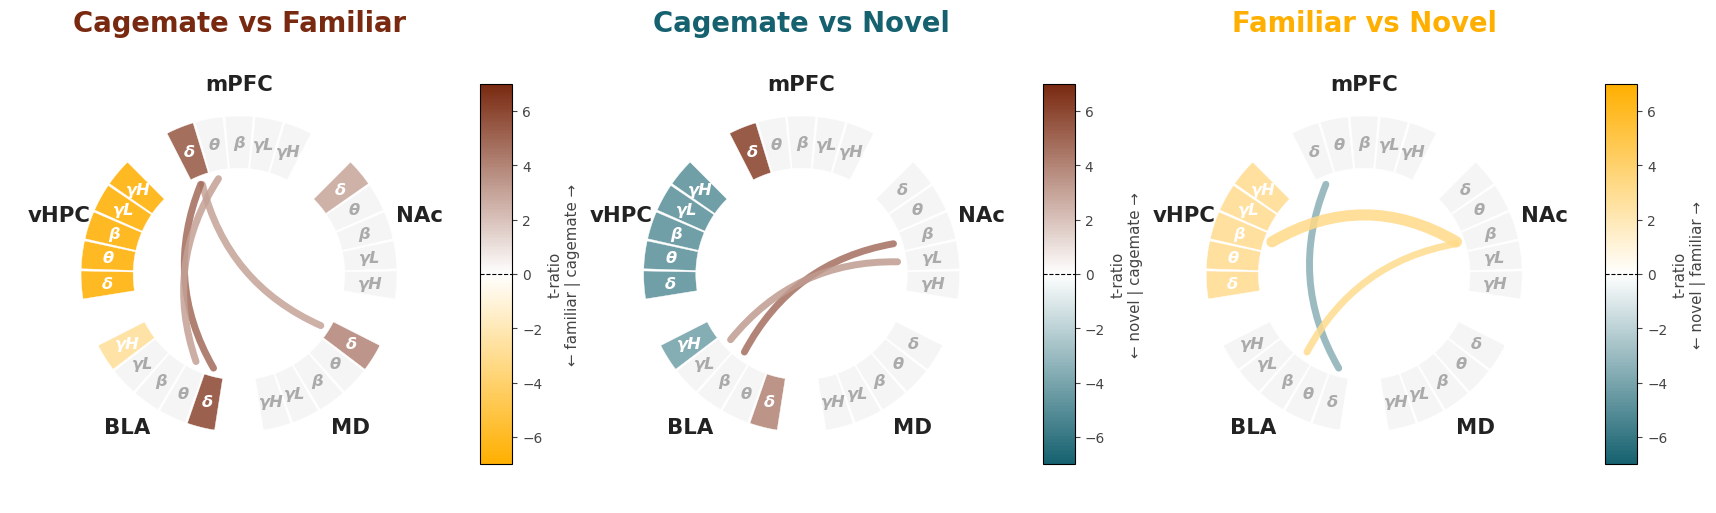

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.cm import ScalarMappable
import pandas as pd

# ── COLORS ────────────────────────────────────────────────────────────────────

agent_colors = {
    "cagemate": "#792910",
    "familiar": "#FFAF00",
    "novel":    "#15616F"
}

# ── LAYOUT ────────────────────────────────────────────────────────────────────

regions    = ["mPFC", "NAc", "MD", "BLA", "vHPC"]
bands      = ["Delta", "Theta", "Beta", "Low gamma", "High gamma"]
band_greek = ["δ", "θ", "β", "γL", "γH"]
FS         = 1.8

contrasts_to_plot = [
    "cagemate - familiar",
    "cagemate - novel",
    "familiar - novel"
]

contrast_labels = {
    "cagemate - familiar": "Cagemate vs Familiar",
    "cagemate - novel":    "Cagemate vs Novel",
    "familiar - novel":    "Familiar vs Novel"
}

contrast_colors = {
    "cagemate - familiar": "#792910",
    "cagemate - novel":    "#15616F",
    "familiar - novel":    "#FFAF00"
}

# ── LOAD DATA ─────────────────────────────────────────────────────────────────

power_emm           = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/power_emm.csv")
coherence_emm       = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/coherence_emm.csv")
power_contrasts     = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/power_contrasts.csv")
coherence_contrasts = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/coherence_contrasts.csv")

# ── FIX CAPITALIZATION ────────────────────────────────────────────────────────

name_fix = {"mPFC_Nac": "mPFC_NAc"}
coherence_emm["region"]       = coherence_emm["region"].replace(name_fix)
coherence_contrasts["region"] = coherence_contrasts["region"].replace(name_fix)
valid_coherence_pairs = coherence_emm["region"].unique().tolist()


REAL_SIG = ["*", "**", "***"]

def is_real_sig(series):
    return series.notna() & series.isin(REAL_SIG)

# ── GLOBAL T.RATIO RANGE ──────────────────────────────────────────────────────

all_t     = pd.concat([power_contrasts["t.ratio"].dropna(),
                        coherence_contrasts["t.ratio"].dropna()])
t_abs_max = np.ceil(all_t.abs().max())
norm      = Normalize(vmin=-t_abs_max, vmax=t_abs_max)

print(f"Global t.ratio range: ±{t_abs_max}")

# ── CONTRAST COLORMAPS ────────────────────────────────────────────────────────

def make_contrast_cmap(contrast_str):
    agents    = [a.strip() for a in contrast_str.split(" - ")]
    color_pos = mcolors.to_rgb(agent_colors[agents[0]])
    color_neg = mcolors.to_rgb(agent_colors[agents[1]])
    white     = (1.0, 1.0, 1.0)
    return LinearSegmentedColormap.from_list(
        f"cmap_{contrast_str}",
        [color_neg, white, color_pos]
    )

contrast_cmaps = {c: make_contrast_cmap(c) for c in contrasts_to_plot}

def t_to_color(t_ratio, contrast, alpha=1.0):
    rgba      = list(contrast_cmaps[contrast](norm(t_ratio)))
    rgba[3]   = alpha
    return tuple(rgba)

# ── GEOMETRY ──────────────────────────────────────────────────────────────────

region_span_deg = 55.0
gap_deg         = (360.0 - region_span_deg * len(regions)) / len(regions)
band_span_deg   = region_span_deg / len(bands)

region_center_angles = {}
start = 90.0
for i, r in enumerate(regions):
    region_center_angles[r] = start - i * (region_span_deg + gap_deg)

def band_center_deg(region, band_idx):
    rc    = region_center_angles[region]
    start = rc + region_span_deg / 2.0
    return start - (band_idx + 0.5) * band_span_deg

def deg2rad(d):
    return np.pi * d / 180.0

def arc_polygon(center_deg, half_deg, r_inner, r_outer, n=60):
    a0     = deg2rad(center_deg - half_deg)
    a1     = deg2rad(center_deg + half_deg)
    angles = np.linspace(a0, a1, n)
    xs     = np.concatenate([r_outer * np.cos(angles),
                              r_inner * np.cos(angles[::-1])])
    ys     = np.concatenate([r_outer * np.sin(angles),
                              r_inner * np.sin(angles[::-1])])
    return xs, ys

def chord_endpoint(region, band_idx, r=0.62):
    angle = deg2rad(band_center_deg(region, band_idx))
    return r * np.cos(angle), r * np.sin(angle)

def parse_pair(pair_name):
    if pair_name not in valid_coherence_pairs:
        return None, None
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None


# ── PLOT FUNCTION ─────────────────────────────────────────────────────────────

def plot_connectogram(ax, cbar_ax, contrast, contrast_color, contrast_label):

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_title(contrast_label,
                 color=contrast_color, fontsize=11 * FS,
                 fontweight="bold", pad=10)

    # ── Build contrast-specific sig filters ───────────────────────────────────
    sig_power_this = power_contrasts[
        power_contrasts["sig"].isin(REAL_SIG) &
        (power_contrasts["contrast"] == contrast)
    ].copy()

    sig_power_main_this = (
        sig_power_this[
            sig_power_this["plot_type"].str.contains("main_effect", na=False)
        ]
        .drop_duplicates(subset=["region"])
        [["region"]]
        .copy()
    )

    sig_coherence_this = (
        coherence_contrasts[
            coherence_contrasts["sig"].isin(REAL_SIG) &
            coherence_contrasts["band"].notna() &
            (coherence_contrasts["contrast"] == contrast)
        ]
        .rename(columns={"region": "pair"})
        .drop_duplicates(subset=["pair", "band"])
        [["pair", "band"]]
        .copy()
    )

    sig_coherence_main_this = (
        coherence_contrasts[
            coherence_contrasts["sig"].isin(REAL_SIG) &
            coherence_contrasts["band"].isna() &
            (coherence_contrasts["contrast"] == contrast)
        ]
        .drop_duplicates(subset=["region"])
        [["region", "t.ratio"]]
        .copy()
    )

    # ── Local significance checker for power ──────────────────────────────────
    def is_sig_power_cell(region, band):
        band_sig = (
            (sig_power_this["region"] == region) &
            (sig_power_this["band"]   == band)
        ).any()
        main_sig = (
            (sig_power_main_this["region"] == region).any() and
            sig_power_this[sig_power_this["region"] == region].shape[0] > 0
        )
        return bool(band_sig or main_sig)

    r_inner = 0.67
    r_outer = 1.00
    half    = band_span_deg / 2.0 - 0.4

    # ── Power arcs ────────────────────────────────────────────────────────────
    for region in regions:
        for bi, (band, greek) in enumerate(zip(bands, band_greek)):

            center = band_center_deg(region, bi)
            is_sig = is_sig_power_cell(region, band)

            if is_sig:
                row = sig_power_this[
                    (sig_power_this["region"] == region) &
                    (sig_power_this["band"]   == band)
                ]
                if len(row) == 0:
                    # main effect fallback — use any sig row for this region
                    row = sig_power_this[sig_power_this["region"] == region]
                t_val = row["t.ratio"].values[0] if len(row) > 0 else 0.0
                color = t_to_color(t_val, contrast=contrast, alpha=0.9)
            else:
                color = (0.85, 0.85, 0.85, 0.25)

            xs, ys = arc_polygon(center, half, r_inner, r_outer)
            ax.fill(xs, ys, color=color, linewidth=0, zorder=2)
            ax.plot(np.append(xs, xs[0]),
                    np.append(ys, ys[0]),
                    color="white", lw=0.3, zorder=3)

            label_r = (r_inner + r_outer) / 2.0
            label_a = deg2rad(center)
            txt_col = "white" if is_sig else "#AAAAAA"
            ax.text(label_r * np.cos(label_a),
                    label_r * np.sin(label_a),
                    greek,
                    ha="center", va="center",
                    fontsize=6.5 * FS,
                    color=txt_col,
                    fontweight="bold",
                    fontstyle="italic",
                    zorder=4)

        # Region label
        label_r = r_outer + 0.2
        label_a = deg2rad(region_center_angles[region])
        ax.text(label_r * np.cos(label_a),
                label_r * np.sin(label_a),
                region,
                ha="center", va="center",
                fontsize=8.5 * FS,
                fontweight="bold",
                color="#222222", zorder=4)

    # ── Coherence chords — band-specific ─────────────────────────────────────
    plotted = set()

    for _, sig_row in sig_coherence_this.iterrows():
        pair = sig_row["pair"]
        band = sig_row["band"]

        if band not in bands:
            continue
        bi = bands.index(band)

        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            continue

        key = (tuple(sorted([r1, r2])), band)
        if key in plotted:
            continue
        plotted.add(key)

        emm_row = coherence_contrasts[
            (coherence_contrasts["region"]   == pair) &
            (coherence_contrasts["band"]     == band) &
            (coherence_contrasts["contrast"] == contrast)
        ]
        if len(emm_row) == 0:
            pair_rev = f"{r2}_{r1}"
            emm_row  = coherence_contrasts[
                (coherence_contrasts["region"]   == pair_rev) &
                (coherence_contrasts["band"]     == band) &
                (coherence_contrasts["contrast"] == contrast)
            ]

        t_val       = emm_row["t.ratio"].values[0] if len(emm_row) > 0 else 0.0
        chord_color = t_to_color(t_val, contrast=contrast, alpha=0.85)

        x1, y1 = chord_endpoint(r1, bi, r=0.63)
        x2, y2 = chord_endpoint(r2, bi, r=0.63)

        ax.annotate("",
            xy      =(x2, y2), xycoords="data",
            xytext  =(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle      = "-",
                color           = chord_color,
                lw              = 5,
                connectionstyle = "arc3,rad=0.25"
            ),
            zorder=1
        )

    # ── Coherence chords — main effect (thick) ────────────────────────────────
    for _, main_row in sig_coherence_main_this.iterrows():
        pair = main_row["region"]
        t    = main_row["t.ratio"]

        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            continue

        chord_color = t_to_color(t, contrast=contrast, alpha=0.85)
        a1       = deg2rad(region_center_angles[r1])
        a2       = deg2rad(region_center_angles[r2])
        r_attach = 0.63
        x1, y1   = r_attach * np.cos(a1), r_attach * np.sin(a1)
        x2, y2   = r_attach * np.cos(a2), r_attach * np.sin(a2)

        ax.annotate("",
            xy      =(x2, y2), xycoords="data",
            xytext  =(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle      = "-",
                color           = chord_color,
                lw              = 8.0,
                connectionstyle = "arc3,rad=0.3"
            ),
            zorder=1
        )

    # ── Colorbar ──────────────────────────────────────────────────────────────
    sm = ScalarMappable(cmap=contrast_cmaps[contrast], norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cb.set_label(
        f"t-ratio\n← {contrast.split(' - ')[1]} | {contrast.split(' - ')[0]} →",
        fontsize=6 * FS, color="#444444"
    )
    cb.ax.tick_params(labelsize=5.5 * FS, colors="#444444")
    cb.ax.axhline(y=0, color="black", lw=0.8, linestyle="--")
fig      = plt.figure(figsize=(21, 8), facecolor="white")
outer_gs = GridSpec(1, 3, wspace=0.12, figure=fig)

axes_main = []
axes_cbar = []

for i in range(3):
    inner_gs = GridSpecFromSubplotSpec(
        3, 2,
        subplot_spec  = outer_gs[i],
        width_ratios  = [1, 0.07],
        height_ratios = [0.15, 0.7, 0.15],
        wspace        = 0.05
    )
    axes_main.append(fig.add_subplot(inner_gs[:, 0]))
    axes_cbar.append(fig.add_subplot(inner_gs[1, 1]))

for ax, cbar_ax, contrast in zip(axes_main, axes_cbar, contrasts_to_plot):
    plot_connectogram(
        ax             = ax,
        cbar_ax        = cbar_ax,
        contrast       = contrast,
        contrast_color = contrast_colors[contrast],
        contrast_label = contrast_labels[contrast]
    )

plt.savefig("connectogram_contrasts.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [6]:
coherence_contrasts[(coherence_contrasts['region'] == 'mPFC_BLA') & (coherence_contrasts['band'] == 'Theta')]

,region,model_formula,plot_type,contrast,band,estimate,SE,df,t.ratio,p.value,p.value.adjusted,sig
33,mPFC_BLA,value ~ band * agent + (1 | X),interaction,cagemate - familiar,Theta,5.773531,1.859727,2036.440893,3.104505,0.001932,0.029287,*
34,mPFC_BLA,value ~ band * agent + (1 | X),interaction,cagemate - novel,Theta,2.326311,1.456481,2038.898425,1.597213,0.110373,0.279482,NaN
35,mPFC_BLA,value ~ band * agent + (1 | X),interaction,familiar - novel,Theta,-3.447220,1.942398,2034.528767,-1.774724,0.076093,0.228279,NaN


Global t.ratio range: ±5.0


TypeError: plot_connectogram.<locals>.is_sig_power_cell() takes 2 positional arguments but 3 were given

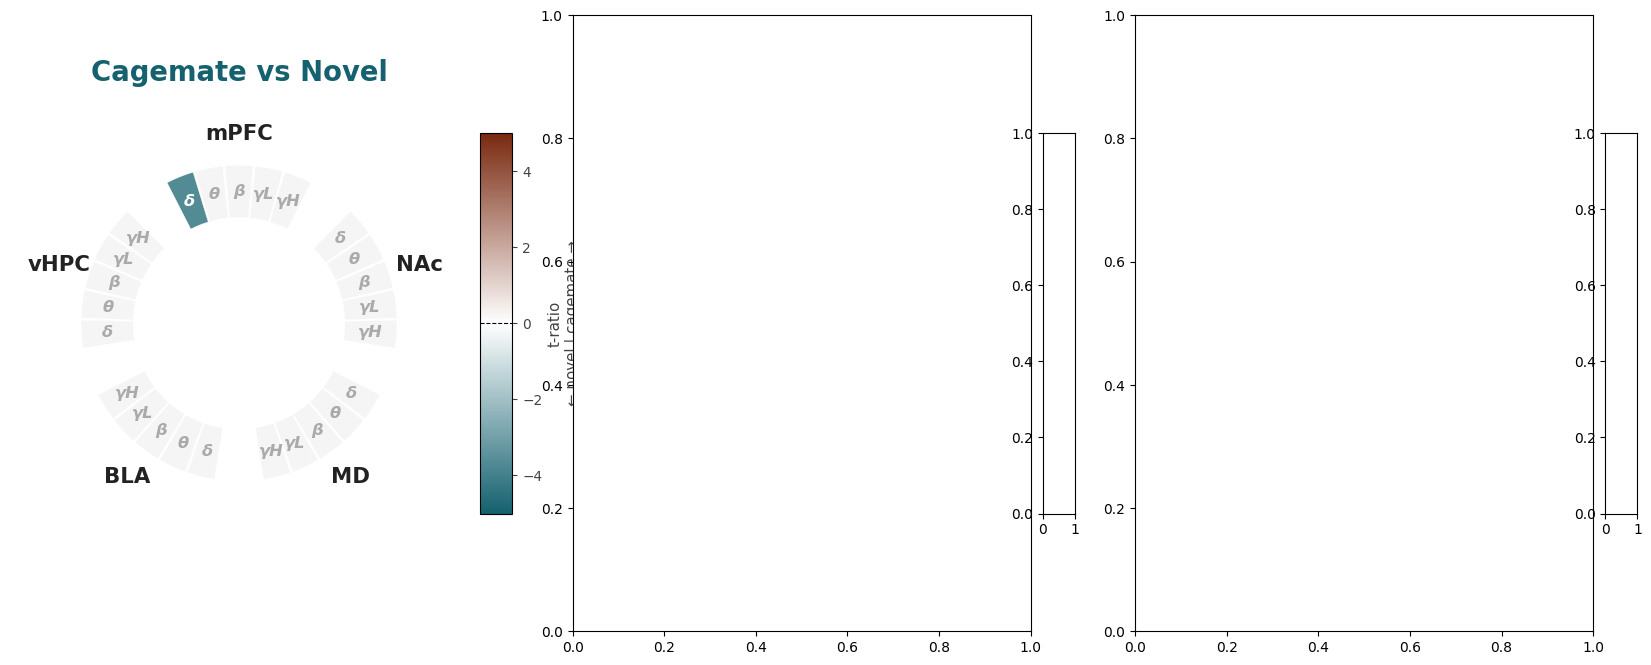

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.cm import ScalarMappable
import pandas as pd

# ── COLORS ────────────────────────────────────────────────────────────────────

agent_colors = {
    "cagemate": "#792910",
    #"familiar": "#FFAF00",
    "novel":    "#15616F"
}

# ── LAYOUT ────────────────────────────────────────────────────────────────────

regions    = ["mPFC", "NAc", "MD", "BLA", "vHPC"]
bands      = ["Delta", "Theta", "Beta", "Low gamma", "High gamma"]
band_greek = ["δ", "θ", "β", "γL", "γH"]
FS         = 1.8

contrasts_to_plot = [
    #"cagemate - familiar",
    "cagemate - novel",
    #"familiar - novel"
]

contrast_labels = {
    #"cagemate - familiar": "Cagemate vs Familiar",
    "cagemate - novel":    "Cagemate vs Novel",
    #"familiar - novel":    "Familiar vs Novel"
}

contrast_colors = {
    #"cagemate - familiar": "#792910",
    "cagemate - novel":    "#15616F",
    #"familiar - novel":    "#FFAF00"
}

# ── LOAD DATA ─────────────────────────────────────────────────────────────────

power_emm           = pd.read_csv("pilot2/habit_dishabit_phase1/r_stuff/cage_v_nov_power_emm.csv")
coherence_emm       = pd.read_csv("pilot2/habit_dishabit_phase1/r_stuff/cage_v_nov_coherence_emm.csv")
power_contrasts     = pd.read_csv("pilot2/habit_dishabit_phase1/r_stuff/cage_v_nov_power_contrasts.csv")
coherence_contrasts = pd.read_csv("pilot2/habit_dishabit_phase1/r_stuff/cage_v_nov_coherence_contrasts.csv")

# ── FIX CAPITALIZATION ────────────────────────────────────────────────────────

name_fix = {"mPFC_Nac": "mPFC_NAc"}
coherence_emm["region"]       = coherence_emm["region"].replace(name_fix)
coherence_contrasts["region"] = coherence_contrasts["region"].replace(name_fix)



# ── GLOBAL T.RATIO RANGE ──────────────────────────────────────────────────────

all_t     = pd.concat([power_contrasts["t.ratio"].dropna(),
                        coherence_contrasts["t.ratio"].dropna()])
t_abs_max = np.ceil(all_t.abs().max())
norm      = Normalize(vmin=-t_abs_max, vmax=t_abs_max)

print(f"Global t.ratio range: ±{t_abs_max}")

# ── CONTRAST COLORMAPS ────────────────────────────────────────────────────────

def make_contrast_cmap(contrast_str):
    agents    = [a.strip() for a in contrast_str.split(" - ")]
    color_pos = mcolors.to_rgb(agent_colors[agents[0]])
    color_neg = mcolors.to_rgb(agent_colors[agents[1]])
    white     = (1.0, 1.0, 1.0)
    return LinearSegmentedColormap.from_list(
        f"cmap_{contrast_str}",
        [color_neg, white, color_pos]
    )

contrast_cmaps = {c: make_contrast_cmap(c) for c in contrasts_to_plot}

def t_to_color(t_ratio, contrast, alpha=1.0):
    rgba      = list(contrast_cmaps[contrast](norm(t_ratio)))
    rgba[3]   = alpha
    return tuple(rgba)

# ── GEOMETRY ──────────────────────────────────────────────────────────────────

region_span_deg = 55.0
gap_deg         = (360.0 - region_span_deg * len(regions)) / len(regions)
band_span_deg   = region_span_deg / len(bands)

region_center_angles = {}
start = 90.0
for i, r in enumerate(regions):
    region_center_angles[r] = start - i * (region_span_deg + gap_deg)

def band_center_deg(region, band_idx):
    rc    = region_center_angles[region]
    start = rc + region_span_deg / 2.0
    return start - (band_idx + 0.5) * band_span_deg

def deg2rad(d):
    return np.pi * d / 180.0

def arc_polygon(center_deg, half_deg, r_inner, r_outer, n=60):
    a0     = deg2rad(center_deg - half_deg)
    a1     = deg2rad(center_deg + half_deg)
    angles = np.linspace(a0, a1, n)
    xs     = np.concatenate([r_outer * np.cos(angles),
                              r_inner * np.cos(angles[::-1])])
    ys     = np.concatenate([r_outer * np.sin(angles),
                              r_inner * np.sin(angles[::-1])])
    return xs, ys

def chord_endpoint(region, band_idx, r=0.62):
    angle = deg2rad(band_center_deg(region, band_idx))
    return r * np.cos(angle), r * np.sin(angle)

def parse_pair(pair_name):
    if pair_name not in valid_coherence_pairs:
        return None, None
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

def is_sig_power_cell(region, band, contrast):
    band_sig = (
        (sig_power["region"]   == region) &
        (sig_power["band"]     == band) &
        (sig_power["contrast"] == contrast)
    ).any()
    main_sig = (
        (sig_power_main["region"] == region).any() and
        (
            power_contrasts[
                (power_contrasts["region"]   == region) &
                (power_contrasts["contrast"] == contrast) &
                is_real_sig(power_contrasts["sig"])
            ].shape[0] > 0
        )
    )
    return bool(band_sig or main_sig)

# ── PLOT FUNCTION ─────────────────────────────────────────────────────────────

def plot_connectogram(ax, cbar_ax, contrast, contrast_color, contrast_label):

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_title(contrast_label,
                 color=contrast_color, fontsize=11 * FS,
                 fontweight="bold", pad=10)

    # ── Build contrast-specific sig filters ───────────────────────────────────
    sig_power_this = power_contrasts[
        power_contrasts["sig"].isin(REAL_SIG) &
        (power_contrasts["contrast"] == contrast)
    ].copy()

    sig_power_main_this = (
        sig_power_this[
            sig_power_this["plot_type"].str.contains("main_effect", na=False)
        ]
        .drop_duplicates(subset=["region"])
        [["region"]]
        .copy()
    )

    sig_coherence_this = (
        coherence_contrasts[
            coherence_contrasts["sig"].isin(REAL_SIG) &
            coherence_contrasts["band"].notna() &
            (coherence_contrasts["contrast"] == contrast)
        ]
        .rename(columns={"region": "pair"})
        .drop_duplicates(subset=["pair", "band"])
        [["pair", "band"]]
        .copy()
    )

    sig_coherence_main_this = (
        coherence_contrasts[
            coherence_contrasts["sig"].isin(REAL_SIG) &
            coherence_contrasts["band"].isna() &
            (coherence_contrasts["contrast"] == contrast)
        ]
        .drop_duplicates(subset=["region"])
        [["region", "t.ratio"]]
        .copy()
    )

    # ── Local significance checker for power ──────────────────────────────────
    def is_sig_power_cell(region, band):
        band_sig = (
            (sig_power_this["region"] == region) &
            (sig_power_this["band"]   == band)
        ).any()
        main_sig = (
            (sig_power_main_this["region"] == region).any() and
            sig_power_this[sig_power_this["region"] == region].shape[0] > 0
        )
        return bool(band_sig or main_sig)

    r_inner = 0.67
    r_outer = 1.00
    half    = band_span_deg / 2.0 - 0.4

    # ── Power arcs ────────────────────────────────────────────────────────────
    for region in regions:
        for bi, (band, greek) in enumerate(zip(bands, band_greek)):

            center = band_center_deg(region, bi)
            is_sig = is_sig_power_cell(region, band)

            if is_sig:
                row = sig_power_this[
                    (sig_power_this["region"] == region) &
                    (sig_power_this["band"]   == band)
                ]
                if len(row) == 0:
                    # main effect fallback — use any sig row for this region
                    row = sig_power_this[sig_power_this["region"] == region]
                t_val = row["t.ratio"].values[0] if len(row) > 0 else 0.0
                color = t_to_color(t_val, contrast=contrast, alpha=0.9)
            else:
                color = (0.85, 0.85, 0.85, 0.25)

            xs, ys = arc_polygon(center, half, r_inner, r_outer)
            ax.fill(xs, ys, color=color, linewidth=0, zorder=2)
            ax.plot(np.append(xs, xs[0]),
                    np.append(ys, ys[0]),
                    color="white", lw=0.3, zorder=3)

            label_r = (r_inner + r_outer) / 2.0
            label_a = deg2rad(center)
            txt_col = "white" if is_sig else "#AAAAAA"
            ax.text(label_r * np.cos(label_a),
                    label_r * np.sin(label_a),
                    greek,
                    ha="center", va="center",
                    fontsize=6.5 * FS,
                    color=txt_col,
                    fontweight="bold",
                    fontstyle="italic",
                    zorder=4)

        # Region label
        label_r = r_outer + 0.2
        label_a = deg2rad(region_center_angles[region])
        ax.text(label_r * np.cos(label_a),
                label_r * np.sin(label_a),
                region,
                ha="center", va="center",
                fontsize=8.5 * FS,
                fontweight="bold",
                color="#222222", zorder=4)

    # ── Coherence chords — band-specific ─────────────────────────────────────
    plotted = set()

    for _, sig_row in sig_coherence_this.iterrows():
        pair = sig_row["pair"]
        band = sig_row["band"]

        if band not in bands:
            continue
        bi = bands.index(band)

        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            continue

        key = (tuple(sorted([r1, r2])), band)
        if key in plotted:
            continue
        plotted.add(key)

        emm_row = coherence_contrasts[
            (coherence_contrasts["region"]   == pair) &
            (coherence_contrasts["band"]     == band) &
            (coherence_contrasts["contrast"] == contrast)
        ]
        if len(emm_row) == 0:
            pair_rev = f"{r2}_{r1}"
            emm_row  = coherence_contrasts[
                (coherence_contrasts["region"]   == pair_rev) &
                (coherence_contrasts["band"]     == band) &
                (coherence_contrasts["contrast"] == contrast)
            ]

        t_val       = emm_row["t.ratio"].values[0] if len(emm_row) > 0 else 0.0
        chord_color = t_to_color(t_val, contrast=contrast, alpha=0.85)

        x1, y1 = chord_endpoint(r1, bi, r=0.63)
        x2, y2 = chord_endpoint(r2, bi, r=0.63)

        ax.annotate("",
            xy      =(x2, y2), xycoords="data",
            xytext  =(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle      = "-",
                color           = chord_color,
                lw              = 5,
                connectionstyle = "arc3,rad=0.25"
            ),
            zorder=1
        )

    # ── Coherence chords — main effect (thick) ────────────────────────────────
    for _, main_row in sig_coherence_main_this.iterrows():
        pair = main_row["region"]
        t    = main_row["t.ratio"]

        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            continue

        chord_color = t_to_color(t, contrast=contrast, alpha=0.85)
        a1       = deg2rad(region_center_angles[r1])
        a2       = deg2rad(region_center_angles[r2])
        r_attach = 0.63
        x1, y1   = r_attach * np.cos(a1), r_attach * np.sin(a1)
        x2, y2   = r_attach * np.cos(a2), r_attach * np.sin(a2)

        ax.annotate("",
            xy      =(x2, y2), xycoords="data",
            xytext  =(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle      = "-",
                color           = chord_color,
                lw              = 8.0,
                connectionstyle = "arc3,rad=0.3"
            ),
            zorder=1
        )

    # ── Colorbar ──────────────────────────────────────────────────────────────
    sm = ScalarMappable(cmap=contrast_cmaps[contrast], norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cb.set_label(
        f"t-ratio\n← {contrast.split(' - ')[1]} | {contrast.split(' - ')[0]} →",
        fontsize=6 * FS, color="#444444"
    )
    cb.ax.tick_params(labelsize=5.5 * FS, colors="#444444")
    cb.ax.axhline(y=0, color="black", lw=0.8, linestyle="--")

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_title(contrast_label,
                 color=contrast_color, fontsize=11 * FS,
                 fontweight="bold", pad=10)

    r_inner = 0.67
    r_outer = 1.00
    half    = band_span_deg / 2.0 - 0.4

    # ── Power arcs ────────────────────────────────────────────────────────────
  

    plotted = set()
    for region in regions:
        for bi, (band, greek) in enumerate(zip(bands, band_greek)):

            center = band_center_deg(region, bi)
            is_sig = is_sig_power_cell(region, band, contrast)

            if is_sig:
                row = power_contrasts[
                    (power_contrasts["region"]   == region) &
                    (power_contrasts["band"]     == band) &
                    (power_contrasts["contrast"] == contrast)
                ]
                if len(row) == 0:
                    row = power_contrasts[
                        (power_contrasts["region"]   == region) &
                        (power_contrasts["contrast"] == contrast) &
                        is_real_sig(power_contrasts["sig"])
                    ]
                t_val = row["t.ratio"].values[0] if len(row) > 0 else 0.0
                color = t_to_color(t_val, contrast=contrast, alpha=0.9)
            else:
                color = (0.85, 0.85, 0.85, 0.25)

            xs, ys = arc_polygon(center, half, r_inner, r_outer)
            ax.fill(xs, ys, color=color, linewidth=0, zorder=2)
            ax.plot(np.append(xs, xs[0]),
                    np.append(ys, ys[0]),
                    color="white", lw=0.3, zorder=3)

            label_r = (r_inner + r_outer) / 2.0
            label_a = deg2rad(center)
            txt_col = "white" if is_sig else "#AAAAAA"
            ax.text(label_r * np.cos(label_a),
                    label_r * np.sin(label_a),
                    greek,
                    ha="center", va="center",
                    fontsize=6.5 * FS,
                    color=txt_col,
                    fontweight="bold",
                    fontstyle="italic",
                    zorder=4)

        # Region label
        label_r = r_outer + 0.2
        label_a = deg2rad(region_center_angles[region])
        ax.text(label_r * np.cos(label_a),
                label_r * np.sin(label_a),
                region,
                ha="center", va="center",
                fontsize=8.5 * FS,
                fontweight="bold",
                color="#222222", zorder=4)

    # ── Coherence chords ──────────────────────────────────────────────────────
    sig_coherence_this = (
        coherence_contrasts[
            is_real_sig(coherence_contrasts["sig"]) &
            coherence_contrasts["band"].notna() &
            (coherence_contrasts["contrast"] == contrast)   # ← filter by contrast
        ]
        .rename(columns={"region": "pair"})
        .drop_duplicates(subset=["pair", "band"])
        [["pair", "band"]]
        .copy()
    )
    plotted = set()

    for _, sig_row in sig_coherence_this.iterrows():
        pair = sig_row["pair"]
        band = sig_row["band"]

        if band not in bands:
            continue
        bi = bands.index(band)

        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            continue

        key = (tuple(sorted([r1, r2])), band)
        if key in plotted:
            continue
        plotted.add(key)

        emm_row = coherence_contrasts[
            (coherence_contrasts["region"]   == pair) &
            (coherence_contrasts["band"]     == band) &
            (coherence_contrasts["contrast"] == contrast)
        ]
        if len(emm_row) == 0:
            pair_rev = f"{r2}_{r1}"
            emm_row  = coherence_contrasts[
                (coherence_contrasts["region"]   == pair_rev) &
                (coherence_contrasts["band"]     == band) &
                (coherence_contrasts["contrast"] == contrast)
            ]

        t_val       = emm_row["t.ratio"].values[0] if len(emm_row) > 0 else 0.0
        chord_color = t_to_color(t_val, contrast=contrast, alpha=0.85)

        x1, y1 = chord_endpoint(r1, bi, r=0.63)
        x2, y2 = chord_endpoint(r2, bi, r=0.63)

        ax.annotate("",
            xy      =(x2, y2), xycoords="data",
            xytext  =(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle      = "-",
                color           = chord_color,
                lw              = 5,
                connectionstyle = "arc3,rad=0.25"
            ),
            zorder=1
        )

    # ── Main effect coherence chord (band = NaN, thick) ───────────────────────
    sig_coherence_main = (
        coherence_contrasts[
            is_real_sig(coherence_contrasts["sig"]) &
            coherence_contrasts["band"].isna() &
            (coherence_contrasts["contrast"] == contrast)
        ]
        .drop_duplicates(subset=["region"])
        [["region", "t.ratio"]]
        .copy()
    )

    for _, main_row in sig_coherence_main.iterrows():
        pair = main_row["region"]
        t    = main_row["t.ratio"]

        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            continue

        chord_color = t_to_color(t, contrast=contrast, alpha=0.85)
        a1       = deg2rad(region_center_angles[r1])
        a2       = deg2rad(region_center_angles[r2])
        r_attach = 0.63
        x1, y1   = r_attach * np.cos(a1), r_attach * np.sin(a1)
        x2, y2   = r_attach * np.cos(a2), r_attach * np.sin(a2)

        ax.annotate("",
            xy      =(x2, y2), xycoords="data",
            xytext  =(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle      = "-",
                color           = chord_color,
                lw              = 8.0,
                connectionstyle = "arc3,rad=0.3"
            ),
            zorder=1
        )

    # ── Colorbar ──────────────────────────────────────────────────────────────
    sm = ScalarMappable(cmap=contrast_cmaps[contrast], norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cb.set_label(
        f"t-ratio\n← {contrast.split(' - ')[1]} | {contrast.split(' - ')[0]} →",
        fontsize=6 * FS, color="#444444"
    )
    cb.ax.tick_params(labelsize=5.5 * FS, colors="#444444")
    cb.ax.axhline(y=0, color="black", lw=0.8, linestyle="--")

# ── RENDER — figure and axes FIRST, then plot loop ───────────────────────────

fig      = plt.figure(figsize=(21, 8), facecolor="white")
outer_gs = GridSpec(1, 3, wspace=0.12, figure=fig)

axes_main = []
axes_cbar = []

for i in range(3):
    inner_gs = GridSpecFromSubplotSpec(
        3, 2,
        subplot_spec  = outer_gs[i],
        width_ratios  = [1, 0.07],
        height_ratios = [0.15, 0.7, 0.15],
        wspace        = 0.05
    )
    axes_main.append(fig.add_subplot(inner_gs[:, 0]))
    axes_cbar.append(fig.add_subplot(inner_gs[1, 1]))

for ax, cbar_ax, contrast in zip(axes_main, axes_cbar, contrasts_to_plot):
    plot_connectogram(
        ax             = ax,
        cbar_ax        = cbar_ax,
        contrast       = contrast,
        contrast_color = contrast_colors[contrast],
        contrast_label = contrast_labels[contrast]
    )

#plt.savefig("connectogram_contrasts.png",
#            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


In [7]:
granger_contrasts[granger_contrasts['sig'].isin(REAL_SIG)]

NameError: name 'granger_contrasts' is not defined

Global t.ratio range: ±7.0


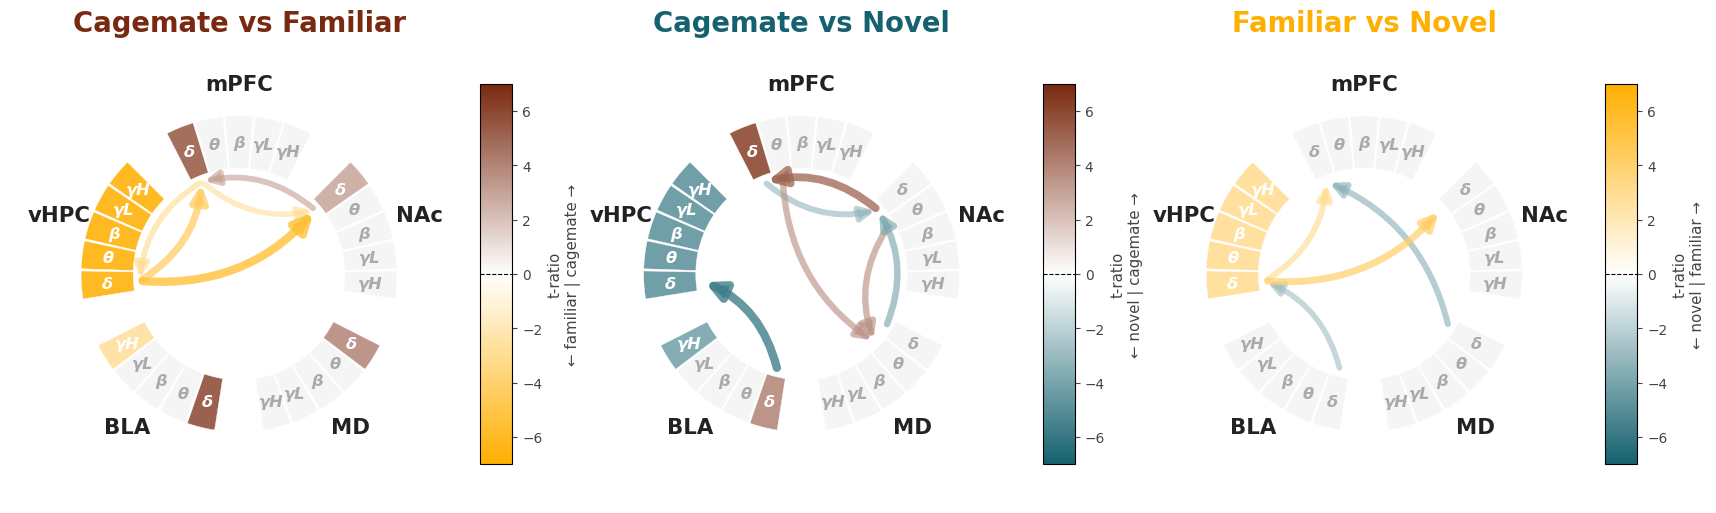

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.cm import ScalarMappable
import pandas as pd

# ── COLORS ────────────────────────────────────────────────────────────────────

agent_colors = {
    "cagemate": "#792910",
    "familiar": "#FFAF00",
    "novel":    "#15616F"
}

# ── LAYOUT ────────────────────────────────────────────────────────────────────

regions    = ["mPFC", "NAc", "MD", "BLA", "vHPC"]
bands      = ["Delta", "Theta", "Beta", "Low gamma", "High gamma"]
band_greek = ["δ", "θ", "β", "γL", "γH"]
FS         = 1.8

contrasts_to_plot = [
    "cagemate - familiar",
    "cagemate - novel",
    "familiar - novel"
]

contrast_labels = {
    "cagemate - familiar": "Cagemate vs Familiar",
    "cagemate - novel":    "Cagemate vs Novel",
    "familiar - novel":    "Familiar vs Novel"
}

contrast_colors = {
    "cagemate - familiar": "#792910",
    "cagemate - novel":    "#15616F",
    "familiar - novel":    "#FFAF00"
}

# ── LOAD DATA ─────────────────────────────────────────────────────────────────

power_emm           = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/power_emm.csv")
coherence_emm       = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/coherence_emm.csv")
granger_emm     = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/granger_emm.csv")

power_contrasts     = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/power_contrasts.csv")
coherence_contrasts = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/coherence_contrasts.csv")
granger_contrasts     = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/granger_contrasts.csv")

# ── FIX CAPITALIZATION ────────────────────────────────────────────────────────

name_fix = {"mPFC_Nac": "mPFC_NAc"}
coherence_emm["region"]       = coherence_emm["region"].replace(name_fix)
coherence_contrasts["region"] = coherence_contrasts["region"].replace(name_fix)
granger_contrasts["region"] = granger_contrasts["region"].replace(name_fix)
granger_emm["region"]       = granger_emm["region"].replace(name_fix)


# ── SIGNIFICANT FILTER ────────────────────────────────────────────────────────

REAL_SIG = ["*", "**", "***"]

def is_real_sig(series):
    return series.notna() & series.isin(REAL_SIG)

sig_power = power_contrasts[is_real_sig(power_contrasts["sig"])].copy()

sig_power_main = (
    power_contrasts[
        is_real_sig(power_contrasts["sig"]) &
        power_contrasts["plot_type"].str.contains("main_effect", na=False)
    ]
    .drop_duplicates(subset=["region"])
    [["region"]]
    .copy()
)

sig_coherence_pairs = (
    coherence_contrasts[
        is_real_sig(coherence_contrasts["sig"]) &
        coherence_contrasts["band"].notna()
    ]
    .rename(columns={"region": "pair"})
    .drop_duplicates(subset=["pair", "band"])
    [["pair", "band"]]
    .copy()
)

sig_granger_pairs = (
    granger_contrasts[
        is_real_sig(granger_contrasts["sig"]) &
        granger_contrasts["band"].notna()
    ]
    .drop_duplicates(subset=["region", "band", "contrast"])
    [["region", "band", "contrast", "t.ratio"]]
    .copy()
)

valid_coherence_pairs = coherence_emm["region"].unique().tolist()

# ── GLOBAL T.RATIO RANGE ──────────────────────────────────────────────────────

all_t     = pd.concat([power_contrasts["t.ratio"].dropna(),
                        coherence_contrasts["t.ratio"].dropna()])
t_abs_max = np.ceil(all_t.abs().max())
norm      = Normalize(vmin=-t_abs_max, vmax=t_abs_max)

print(f"Global t.ratio range: ±{t_abs_max}")

# ── CONTRAST COLORMAPS ────────────────────────────────────────────────────────

def make_contrast_cmap(contrast_str):
    agents    = [a.strip() for a in contrast_str.split(" - ")]
    color_pos = mcolors.to_rgb(agent_colors[agents[0]])
    color_neg = mcolors.to_rgb(agent_colors[agents[1]])
    white     = (1.0, 1.0, 1.0)
    return LinearSegmentedColormap.from_list(
        f"cmap_{contrast_str}",
        [color_neg, white, color_pos]
    )

contrast_cmaps = {c: make_contrast_cmap(c) for c in contrasts_to_plot}

def t_to_color(t_ratio, contrast, alpha=1.0):
    rgba      = list(contrast_cmaps[contrast](norm(t_ratio)))
    rgba[3]   = alpha
    return tuple(rgba)

def parse_pair(pair_name):
    """For coherence — only valid if in coherence EMM."""
    if pair_name not in valid_coherence_pairs:
        return None, None
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

def parse_any_pair(pair_name):
    """For granger — parses A_to_B where both A, B are in regions."""
    if "_to_" in pair_name:
        parts = pair_name.split("_to_")
        if len(parts) == 2 and parts[0] in regions and parts[1] in regions:
            return parts[0], parts[1]
    # fallback: try plain A_B format
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

# ── GEOMETRY ──────────────────────────────────────────────────────────────────

region_span_deg = 55.0
gap_deg         = (360.0 - region_span_deg * len(regions)) / len(regions)
band_span_deg   = region_span_deg / len(bands)

region_center_angles = {}
start = 90.0
for i, r in enumerate(regions):
    region_center_angles[r] = start - i * (region_span_deg + gap_deg)

def band_center_deg(region, band_idx):
    rc    = region_center_angles[region]
    start = rc + region_span_deg / 2.0
    return start - (band_idx + 0.5) * band_span_deg

def deg2rad(d):
    return np.pi * d / 180.0

def arc_polygon(center_deg, half_deg, r_inner, r_outer, n=60):
    a0     = deg2rad(center_deg - half_deg)
    a1     = deg2rad(center_deg + half_deg)
    angles = np.linspace(a0, a1, n)
    xs     = np.concatenate([r_outer * np.cos(angles),
                              r_inner * np.cos(angles[::-1])])
    ys     = np.concatenate([r_outer * np.sin(angles),
                              r_inner * np.sin(angles[::-1])])
    return xs, ys

def chord_endpoint(region, band_idx, r=0.62):
    angle = deg2rad(band_center_deg(region, band_idx))
    return r * np.cos(angle), r * np.sin(angle)

def parse_pair(pair_name):
    if pair_name not in valid_coherence_pairs:
        return None, None
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

def is_sig_power_cell(region, band, contrast):
    band_sig = (
        (sig_power["region"]   == region) &
        (sig_power["band"]     == band) &
        (sig_power["contrast"] == contrast)
    ).any()
    main_sig = (
        (sig_power_main["region"] == region).any() and
        (
            power_contrasts[
                (power_contrasts["region"]   == region) &
                (power_contrasts["contrast"] == contrast) &
                is_real_sig(power_contrasts["sig"])
            ].shape[0] > 0
        )
    )
    return bool(band_sig or main_sig)

# ── PLOT FUNCTION ─────────────────────────────────────────────────────────────

def plot_granger_connectogram(ax, cbar_ax, contrast, contrast_color, contrast_label):

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_title(contrast_label,
                 color=contrast_color, fontsize=11 * FS,
                 fontweight="bold", pad=10)

    r_inner = 0.67
    r_outer = 1.00
    half    = band_span_deg / 2.0 - 0.4

    # ── Power arcs ────────────────────────────────────────────────────────────
    for region in regions:
        for bi, (band, greek) in enumerate(zip(bands, band_greek)):
            center = band_center_deg(region, bi)
            is_sig = is_sig_power_cell(region, band, contrast)

            if is_sig:
                row = power_contrasts[
                    (power_contrasts["region"]   == region) &
                    (power_contrasts["band"]     == band) &
                    (power_contrasts["contrast"] == contrast)
                ]
                if len(row) == 0:
                    row = power_contrasts[
                        (power_contrasts["region"]   == region) &
                        (power_contrasts["contrast"] == contrast) &
                        is_real_sig(power_contrasts["sig"])
                    ]
                t_val = row["t.ratio"].values[0] if len(row) > 0 else 0.0
                color = t_to_color(t_val, contrast=contrast, alpha=0.9)
            else:
                color = (0.85, 0.85, 0.85, 0.25)

            xs, ys = arc_polygon(center, half, r_inner, r_outer)
            ax.fill(xs, ys, color=color, linewidth=0, zorder=2)
            ax.plot(np.append(xs, xs[0]),
                    np.append(ys, ys[0]),
                    color="white", lw=0.3, zorder=3)

            label_r = (r_inner + r_outer) / 2.0
            label_a = deg2rad(center)
            txt_col = "white" if is_sig else "#AAAAAA"
            ax.text(label_r * np.cos(label_a),
                    label_r * np.sin(label_a),
                    greek,
                    ha="center", va="center",
                    fontsize=6.5 * FS,
                    color=txt_col,
                    fontweight="bold",
                    fontstyle="italic",
                    zorder=4)

        # region label
        label_r = r_outer + 0.2
        label_a = deg2rad(region_center_angles[region])
        ax.text(label_r * np.cos(label_a),
                label_r * np.sin(label_a),
                region,
                ha="center", va="center",
                fontsize=8.5 * FS,
                fontweight="bold",
                color="#222222", zorder=4)

    # ── Granger directed arrows ───────────────────────────────────────────────
    gran_contrast = sig_granger_pairs[
        sig_granger_pairs["contrast"] == contrast
    ].copy()

    for _, row in gran_contrast.iterrows():
        pair = row["region"]
        band = row["band"]
        t    = row["t.ratio"]

        if band not in bands:
            continue
        bi = bands.index(band)

        r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue

        t_norm_mag  = min(abs(t) / t_abs_max, 1.0)
        arrow_color = t_to_color(t, contrast=contrast, alpha=0.4 + 0.5 * t_norm_mag)
        lw          = 2 + 5 * t_norm_mag   # 2–7 range
        arrow_size  = 12 + 18 * t_norm_mag  # 12–30 range

        x1, y1 = chord_endpoint(r1, bi, r=0.63)
        x2, y2 = chord_endpoint(r2, bi, r=0.63)

        ax.annotate("",
            xy      =(x2, y2), xycoords="data",
            xytext  =(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle      = f"-|>",
                color           = arrow_color,
                lw              = lw,
                mutation_scale  = arrow_size,
                connectionstyle = "arc3,rad=0.25"
            ),
            zorder=3
        )

    # ── Colorbar ──────────────────────────────────────────────────────────────
    sm = ScalarMappable(cmap=contrast_cmaps[contrast], norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cb.set_label(
        f"t-ratio\n← {contrast.split(' - ')[1]} | {contrast.split(' - ')[0]} →",
        fontsize=6 * FS, color="#444444"
    )
    cb.ax.tick_params(labelsize=5.5 * FS, colors="#444444")
    cb.ax.axhline(y=0, color="black", lw=0.8, linestyle="--")


# ── RENDER ────────────────────────────────────────────────────────────────────

fig      = plt.figure(figsize=(21, 8), facecolor="white")
outer_gs = GridSpec(1, 3, wspace=0.12, figure=fig)

axes_main = []
axes_cbar = []

for i in range(3):
    inner_gs = GridSpecFromSubplotSpec(
        3, 2,
        subplot_spec  = outer_gs[i],
        width_ratios  = [1, 0.07],
        height_ratios = [0.15, 0.7, 0.15],
        wspace        = 0.05
    )
    axes_main.append(fig.add_subplot(inner_gs[:, 0]))
    axes_cbar.append(fig.add_subplot(inner_gs[1, 1]))

for ax, cbar_ax, contrast in zip(axes_main, axes_cbar, contrasts_to_plot):
    plot_granger_connectogram(
        ax             = ax,
        cbar_ax        = cbar_ax,
        contrast       = contrast,
        contrast_color = contrast_colors[contrast],
        contrast_label = contrast_labels[contrast]
    )

plt.savefig("connectogram_granger.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

Global t.ratio range: ±7.0


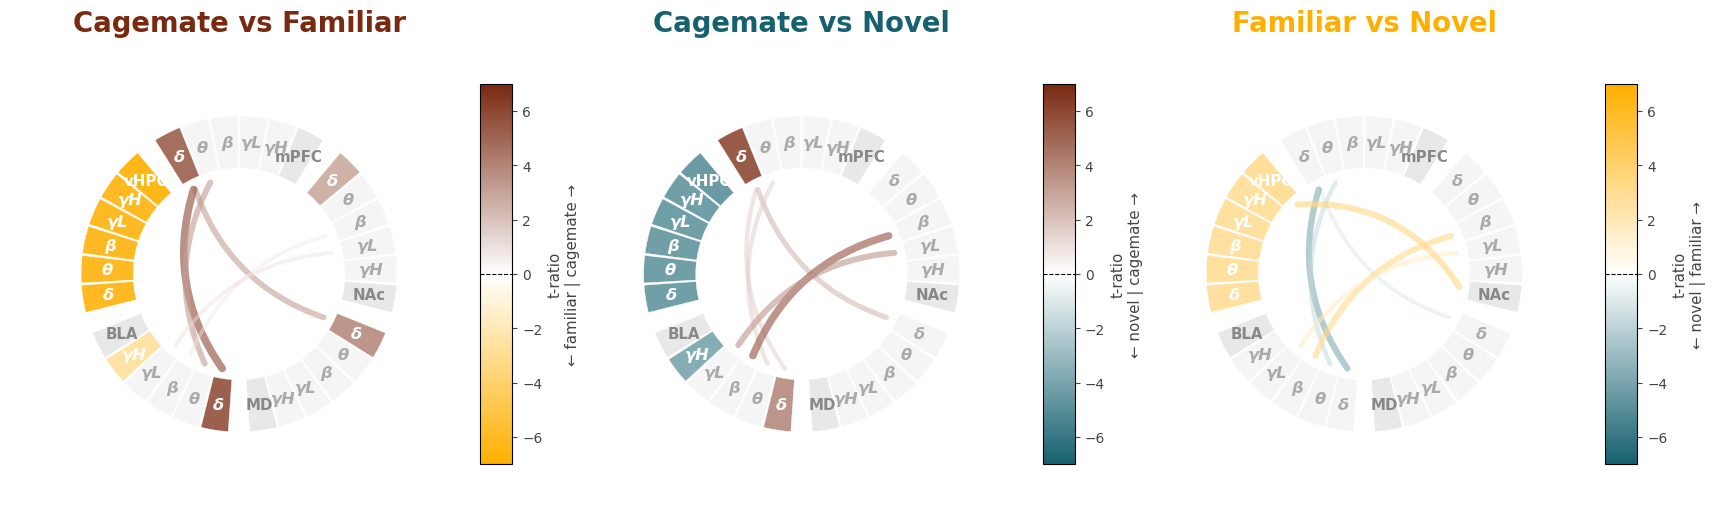

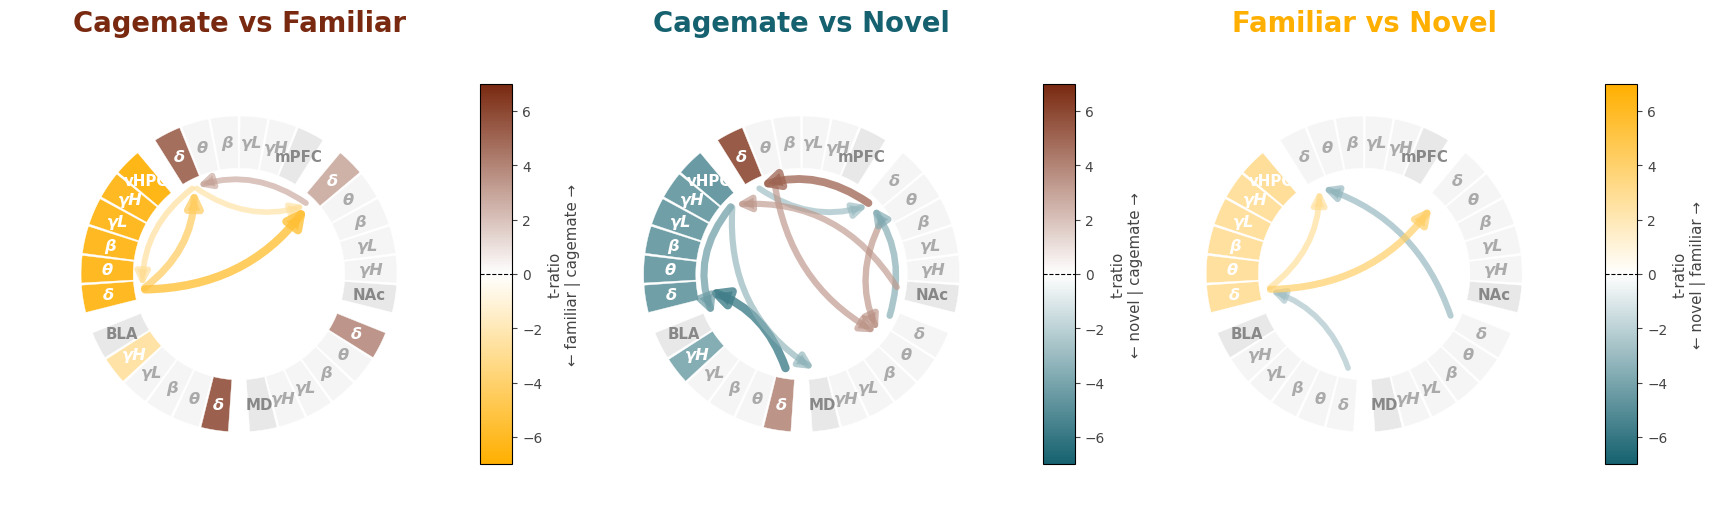

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.cm import ScalarMappable
import pandas as pd

# ── COLORS ────────────────────────────────────────────────────────────────────

agent_colors = {
    "cagemate": "#792910",
    "familiar": "#FFAF00",
    "novel":    "#15616F"
}

# ── LAYOUT ────────────────────────────────────────────────────────────────────

regions    = ["mPFC", "NAc", "MD", "BLA", "vHPC"]
bands      = ["Delta", "Theta", "Beta", "Low gamma", "High gamma"]
band_greek = ["δ", "θ", "β", "γL", "γH"]
FS         = 1.8

contrasts_to_plot = [
    "cagemate - familiar",
    "cagemate - novel",
    "familiar - novel"
]

contrast_labels = {
    "cagemate - familiar": "Cagemate vs Familiar",
    "cagemate - novel":    "Cagemate vs Novel",
    "familiar - novel":    "Familiar vs Novel"
}

contrast_colors = {
    "cagemate - familiar": "#792910",
    "cagemate - novel":    "#15616F",
    "familiar - novel":    "#FFAF00"
}

# ── LOAD DATA ─────────────────────────────────────────────────────────────────

power_emm           = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/power_emm.csv")
coherence_emm       = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/coherence_emm.csv")
granger_emm         = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/granger_emm.csv")
power_contrasts     = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/power_contrasts.csv")
coherence_contrasts = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/coherence_contrasts.csv")
granger_contrasts   = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/granger_contrasts.csv")

# ── FIX CAPITALIZATION ────────────────────────────────────────────────────────

name_fix = {"mPFC_Nac": "mPFC_NAc"}
coherence_emm["region"]       = coherence_emm["region"].replace(name_fix)
coherence_contrasts["region"] = coherence_contrasts["region"].replace(name_fix)
granger_contrasts["region"]   = granger_contrasts["region"].replace(name_fix)
granger_emm["region"]         = granger_emm["region"].replace(name_fix)

# ── SIGNIFICANT FILTER ────────────────────────────────────────────────────────

REAL_SIG = ["*", "**", "***"]

def is_real_sig(series):
    return series.notna() & series.isin(REAL_SIG)

sig_power = power_contrasts[is_real_sig(power_contrasts["sig"])].copy()

sig_power_main = (
    power_contrasts[
        is_real_sig(power_contrasts["sig"]) &
        power_contrasts["plot_type"].str.contains("main_effect", na=False)
    ]
    .drop_duplicates(subset=["region"])
    [["region"]]
    .copy()
)

sig_coherence_pairs = (
    coherence_contrasts[
        is_real_sig(coherence_contrasts["sig"]) &
        coherence_contrasts["band"].notna()
    ]
    .rename(columns={"region": "pair"})
    .drop_duplicates(subset=["pair", "band"])
    [["pair", "band"]]
    .copy()
)

sig_granger_pairs = (
    granger_contrasts[
        is_real_sig(granger_contrasts["sig"]) &
        granger_contrasts["band"].notna()
    ]
    .drop_duplicates(subset=["region", "band", "contrast"])
    [["region", "band", "contrast", "t.ratio"]]
    .copy()
)

valid_coherence_pairs = coherence_emm["region"].unique().tolist()

# ── GLOBAL T.RATIO RANGE ──────────────────────────────────────────────────────

all_t     = pd.concat([power_contrasts["t.ratio"].dropna(),
                       coherence_contrasts["t.ratio"].dropna()])
t_abs_max = np.ceil(all_t.abs().max())
norm      = Normalize(vmin=-t_abs_max, vmax=t_abs_max)

print(f"Global t.ratio range: ±{t_abs_max}")

# ── CONTRAST COLORMAPS ────────────────────────────────────────────────────────

def make_contrast_cmap(contrast_str):
    agents    = [a.strip() for a in contrast_str.split(" - ")]
    color_pos = mcolors.to_rgb(agent_colors[agents[0]])
    color_neg = mcolors.to_rgb(agent_colors[agents[1]])
    white     = (1.0, 1.0, 1.0)
    return LinearSegmentedColormap.from_list(
        f"cmap_{contrast_str}",
        [color_neg, white, color_pos]
    )

contrast_cmaps = {c: make_contrast_cmap(c) for c in contrasts_to_plot}

def t_to_color(t_ratio, contrast, alpha=1.0):
    rgba    = list(contrast_cmaps[contrast](norm(t_ratio)))
    rgba[3] = alpha
    return tuple(rgba)

# ── GEOMETRY ──────────────────────────────────────────────────────────────────

n_blocks        = len(bands) + 1                                          # 5 bands + 1 region block
region_span_deg = 65.0
gap_deg         = (360.0 - region_span_deg * len(regions)) / len(regions)
band_span_deg   = region_span_deg / n_blocks

region_center_angles = {}
start = 90.0
for i, r in enumerate(regions):
    region_center_angles[r] = start - i * (region_span_deg + gap_deg)

def band_center_deg(region, block_idx):
    rc    = region_center_angles[region]
    start = rc + region_span_deg / 2.0
    return start - (block_idx + 0.5) * band_span_deg

def region_block_center_deg(region):
    return band_center_deg(region, len(bands))   # last block

def deg2rad(d):
    return np.pi * d / 180.0

def arc_polygon(center_deg, half_deg, r_inner, r_outer, n=60):
    a0     = deg2rad(center_deg - half_deg)
    a1     = deg2rad(center_deg + half_deg)
    angles = np.linspace(a0, a1, n)
    xs     = np.concatenate([r_outer * np.cos(angles),
                              r_inner * np.cos(angles[::-1])])
    ys     = np.concatenate([r_outer * np.sin(angles),
                              r_inner * np.sin(angles[::-1])])
    return xs, ys

def chord_endpoint(region, block_idx, r=0.62):
    angle = deg2rad(band_center_deg(region, block_idx))
    return r * np.cos(angle), r * np.sin(angle)

def region_block_endpoint(region, r=0.62):
    angle = deg2rad(region_block_center_deg(region))
    return r * np.cos(angle), r * np.sin(angle)

def parse_pair(pair_name):
    if pair_name not in valid_coherence_pairs:
        return None, None
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

def parse_any_pair(pair_name):
    if "_to_" in pair_name:
        parts = pair_name.split("_to_")
        if len(parts) == 2 and parts[0] in regions and parts[1] in regions:
            return parts[0], parts[1]
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

def is_sig_power_cell(region, band, contrast):
    band_sig = (
        (sig_power["region"]   == region) &
        (sig_power["band"]     == band) &
        (sig_power["contrast"] == contrast)
    ).any()
    main_sig = (
        (sig_power_main["region"] == region).any() and
        (
            power_contrasts[
                (power_contrasts["region"]   == region) &
                (power_contrasts["contrast"] == contrast) &
                is_real_sig(power_contrasts["sig"])
            ].shape[0] > 0
        )
    )
    return bool(band_sig or main_sig)

# ── COHERENCE PLOT FUNCTION ───────────────────────────────────────────────────

def plot_connectogram(ax, cbar_ax, contrast, contrast_color, contrast_label):

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_title(contrast_label,
                 color=contrast_color, fontsize=11 * FS,
                 fontweight="bold", pad=10)

    r_inner = 0.67
    r_outer = 1.00
    half    = band_span_deg / 2.0 - 0.4

    # ── band blocks + region block ────────────────────────────────────────────
    for region in regions:

        # band blocks (0–4)
        for bi, (band, greek) in enumerate(zip(bands, band_greek)):
            center = band_center_deg(region, bi)
            is_sig = is_sig_power_cell(region, band, contrast)

            if is_sig:
                row = power_contrasts[
                    (power_contrasts["region"]   == region) &
                    (power_contrasts["band"]     == band) &
                    (power_contrasts["contrast"] == contrast)
                ]
                if len(row) == 0:
                    row = power_contrasts[
                        (power_contrasts["region"]   == region) &
                        (power_contrasts["contrast"] == contrast) &
                        is_real_sig(power_contrasts["sig"])
                    ]
                t_val = row["t.ratio"].values[0] if len(row) > 0 else 0.0
                color = t_to_color(t_val, contrast=contrast, alpha=0.9)
            else:
                color = (0.85, 0.85, 0.85, 0.25)

            xs, ys = arc_polygon(center, half, r_inner, r_outer)
            ax.fill(xs, ys, color=color, linewidth=0, zorder=2)
            ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                    color="white", lw=0.3, zorder=3)

            label_r = (r_inner + r_outer) / 2.0
            label_a = deg2rad(center)
            txt_col = "white" if is_sig else "#AAAAAA"
            ax.text(label_r * np.cos(label_a), label_r * np.sin(label_a),
                    greek,
                    ha="center", va="center",
                    fontsize=6.5 * FS, color=txt_col,
                    fontweight="bold", fontstyle="italic", zorder=4)

        # region block (index 5) — colored by main effect power
        center   = region_block_center_deg(region)
        main_row = power_contrasts[
            (power_contrasts["region"]   == region) &
            (power_contrasts["contrast"] == contrast) &
            power_contrasts["band"].isna() &
            is_real_sig(power_contrasts["sig"])
        ]
        if not main_row.empty:
            t_val       = main_row["t.ratio"].values[0]
            block_color = t_to_color(t_val, contrast=contrast, alpha=0.95)
            txt_col     = "white"
        else:
            block_color = (0.75, 0.75, 0.75, 0.35)
            txt_col     = "#888888"

        xs, ys = arc_polygon(center, half, r_inner, r_outer)
        ax.fill(xs, ys, color=block_color, linewidth=0, zorder=2)
        ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                color="white", lw=0.3, zorder=3)

        label_r = (r_inner + r_outer) / 2.0
        label_a = deg2rad(center)
        ax.text(label_r * np.cos(label_a), label_r * np.sin(label_a),
                region,
                ha="center", va="center",
                fontsize=6.0 * FS, color=txt_col,
                fontweight="bold", zorder=4)

    # ── band-level coherence chords ───────────────────────────────────────────
    plotted = set()
    for _, row in sig_coherence_pairs.iterrows():
        pair = row["pair"]
        band = row["band"]
        if band not in bands:
            continue
        bi     = bands.index(band)
        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue
        key = (pair, band)
        if key in plotted:
            continue
        plotted.add(key)

        coh_row = coherence_contrasts[
            (coherence_contrasts["region"].isin([pair, f"{r2}_{r1}"])) &
            (coherence_contrasts["band"]     == band) &
            (coherence_contrasts["contrast"] == contrast)
        ]
        if coh_row.empty:
            continue
        t_coh       = coh_row["t.ratio"].values[0]
        t_norm_mag  = min(abs(t_coh) / t_abs_max, 1.0)
        chord_color = t_to_color(t_coh, contrast=contrast,
                                 alpha=0.4 + 0.5 * t_norm_mag)
        x1, y1 = chord_endpoint(r1, bi)
        x2, y2 = chord_endpoint(r2, bi)

        ax.annotate("",
            xy=(x2, y2), xycoords="data",
            xytext=(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle="-", color=chord_color,
                lw=2 + 5 * t_norm_mag,
                connectionstyle="arc3,rad=0.25"
            ),
            zorder=1
        )

    # ── main effect coherence chords (region block → region block) ────────────
    sig_coh_main = (
        coherence_contrasts[
            is_real_sig(coherence_contrasts["sig"]) &
            coherence_contrasts["band"].isna() &
            (coherence_contrasts["contrast"] == contrast)
        ]
        .drop_duplicates(subset=["region"])
        [["region", "t.ratio"]]
        .copy()
    )
    for _, mrow in sig_coh_main.iterrows():
        pair   = mrow["region"]
        t      = mrow["t.ratio"]
        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue
        t_norm_mag  = min(abs(t) / t_abs_max, 1.0)
        chord_color = t_to_color(t, contrast=contrast,
                                 alpha=0.4 + 0.5 * t_norm_mag)
        x1, y1 = region_block_endpoint(r1)
        x2, y2 = region_block_endpoint(r2)

        ax.annotate("",
            xy=(x2, y2), xycoords="data",
            xytext=(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle="-", color=chord_color,
                lw=2 + 5 * t_norm_mag,
                connectionstyle="arc3,rad=0.3"
            ),
            zorder=1
        )

    # ── colorbar ──────────────────────────────────────────────────────────────
    sm = ScalarMappable(cmap=contrast_cmaps[contrast], norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cb.set_label(
        f"t-ratio\n← {contrast.split(' - ')[1]} | {contrast.split(' - ')[0]} →",
        fontsize=6 * FS, color="#444444"
    )
    cb.ax.tick_params(labelsize=5.5 * FS, colors="#444444")
    cb.ax.axhline(y=0, color="black", lw=0.8, linestyle="--")


# ── GRANGER PLOT FUNCTION ─────────────────────────────────────────────────────

def plot_granger_connectogram(ax, cbar_ax, contrast, contrast_color, contrast_label):

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_title(contrast_label,
                 color=contrast_color, fontsize=11 * FS,
                 fontweight="bold", pad=10)

    r_inner = 0.67
    r_outer = 1.00
    half    = band_span_deg / 2.0 - 0.4

    # ── band blocks + region block ────────────────────────────────────────────
    for region in regions:

        # band blocks (0–4)
        for bi, (band, greek) in enumerate(zip(bands, band_greek)):
            center = band_center_deg(region, bi)
            is_sig = is_sig_power_cell(region, band, contrast)

            if is_sig:
                row = power_contrasts[
                    (power_contrasts["region"]   == region) &
                    (power_contrasts["band"]     == band) &
                    (power_contrasts["contrast"] == contrast)
                ]
                if len(row) == 0:
                    row = power_contrasts[
                        (power_contrasts["region"]   == region) &
                        (power_contrasts["contrast"] == contrast) &
                        is_real_sig(power_contrasts["sig"])
                    ]
                t_val = row["t.ratio"].values[0] if len(row) > 0 else 0.0
                color = t_to_color(t_val, contrast=contrast, alpha=0.9)
            else:
                color = (0.85, 0.85, 0.85, 0.25)

            xs, ys = arc_polygon(center, half, r_inner, r_outer)
            ax.fill(xs, ys, color=color, linewidth=0, zorder=2)
            ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                    color="white", lw=0.3, zorder=3)

            label_r = (r_inner + r_outer) / 2.0
            label_a = deg2rad(center)
            txt_col = "white" if is_sig else "#AAAAAA"
            ax.text(label_r * np.cos(label_a), label_r * np.sin(label_a),
                    greek,
                    ha="center", va="center",
                    fontsize=6.5 * FS, color=txt_col,
                    fontweight="bold", fontstyle="italic", zorder=4)

        # region block (index 5) — colored by main effect power
        center   = region_block_center_deg(region)
        main_row = power_contrasts[
            (power_contrasts["region"]   == region) &
            (power_contrasts["contrast"] == contrast) &
            power_contrasts["band"].isna() &
            is_real_sig(power_contrasts["sig"])
        ]
        if not main_row.empty:
            t_val       = main_row["t.ratio"].values[0]
            block_color = t_to_color(t_val, contrast=contrast, alpha=0.95)
            txt_col     = "white"
        else:
            block_color = (0.75, 0.75, 0.75, 0.35)
            txt_col     = "#888888"

        xs, ys = arc_polygon(center, half, r_inner, r_outer)
        ax.fill(xs, ys, color=block_color, linewidth=0, zorder=2)
        ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                color="white", lw=0.3, zorder=3)

        label_r = (r_inner + r_outer) / 2.0
        label_a = deg2rad(center)
        ax.text(label_r * np.cos(label_a), label_r * np.sin(label_a),
                region,
                ha="center", va="center",
                fontsize=6.0 * FS, color=txt_col,
                fontweight="bold", zorder=4)

    # ── band-level granger arrows ─────────────────────────────────────────────
    gran_contrast = sig_granger_pairs[
        sig_granger_pairs["contrast"] == contrast
    ].copy()

    for _, row in gran_contrast.iterrows():
        pair = row["region"]
        band = row["band"]
        t    = row["t.ratio"]
        if band not in bands:
            continue
        bi     = bands.index(band)
        r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue

        t_norm_mag  = min(abs(t) / t_abs_max, 1.0)
        arrow_color = t_to_color(t, contrast=contrast,
                                 alpha=0.4 + 0.5 * t_norm_mag)
        x1, y1 = chord_endpoint(r1, bi)
        x2, y2 = chord_endpoint(r2, bi)

        ax.annotate("",
            xy=(x2, y2), xycoords="data",
            xytext=(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle="-|>",
                color=arrow_color,
                lw=2 + 5 * t_norm_mag,
                mutation_scale=12 + 18 * t_norm_mag,
                connectionstyle="arc3,rad=0.25"
            ),
            zorder=3
        )

    # ── main effect granger arrows (region block → region block) ─────────────
    gran_main = granger_contrasts[
        is_real_sig(granger_contrasts["sig"]) &
        granger_contrasts["band"].isna() &
        (granger_contrasts["contrast"] == contrast)
    ].copy()

    for _, mrow in gran_main.iterrows():
        pair   = mrow["region"]
        t      = mrow["t.ratio"]
        r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue

        t_norm_mag  = min(abs(t) / t_abs_max, 1.0)
        arrow_color = t_to_color(t, contrast=contrast,
                                 alpha=0.4 + 0.5 * t_norm_mag)
        x1, y1 = region_block_endpoint(r1)
        x2, y2 = region_block_endpoint(r2)

        ax.annotate("",
            xy=(x2, y2), xycoords="data",
            xytext=(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle="-|>",
                color=arrow_color,
                lw=2 + 5 * t_norm_mag,
                mutation_scale=12 + 18 * t_norm_mag,
                connectionstyle="arc3,rad=0.3"
            ),
            zorder=3
        )

    # ── colorbar ──────────────────────────────────────────────────────────────
    sm = ScalarMappable(cmap=contrast_cmaps[contrast], norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cb.set_label(
        f"t-ratio\n← {contrast.split(' - ')[1]} | {contrast.split(' - ')[0]} →",
        fontsize=6 * FS, color="#444444"
    )
    cb.ax.tick_params(labelsize=5.5 * FS, colors="#444444")
    cb.ax.axhline(y=0, color="black", lw=0.8, linestyle="--")


# ── RENDER BOTH FIGURES ───────────────────────────────────────────────────────

for plot_fn, fname, title in [
    (plot_connectogram,         "connectogram_coherence.png", "Coherence"),
    (plot_granger_connectogram, "connectogram_granger.png",   "Granger"),
]:
    fig      = plt.figure(figsize=(21, 8), facecolor="white")
    outer_gs = GridSpec(1, 3, wspace=0.12, figure=fig)

    for i, contrast in enumerate(contrasts_to_plot):
        inner_gs = GridSpecFromSubplotSpec(
            3, 2,
            subplot_spec  = outer_gs[i],
            width_ratios  = [1, 0.07],
            height_ratios = [0.15, 0.7, 0.15],
            wspace        = 0.05
        )
        ax      = fig.add_subplot(inner_gs[:, 0])
        cbar_ax = fig.add_subplot(inner_gs[1, 1])
        plot_fn(
            ax             = ax,
            cbar_ax        = cbar_ax,
            contrast       = contrast,
            contrast_color = contrast_colors[contrast],
            contrast_label = contrast_labels[contrast]
        )

    plt.savefig(fname, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

Global t.ratio range: ±5.0


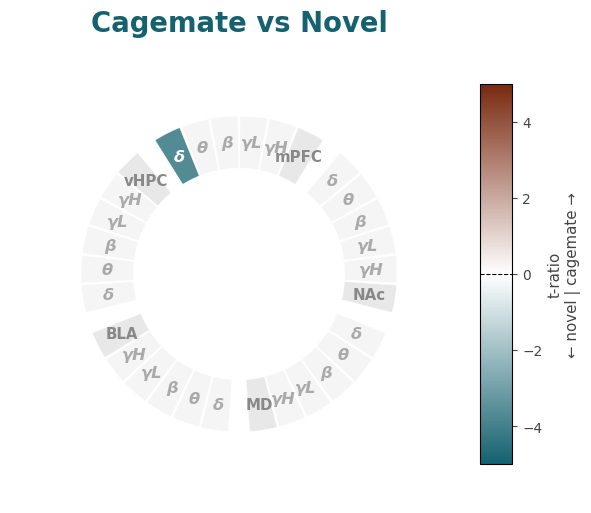

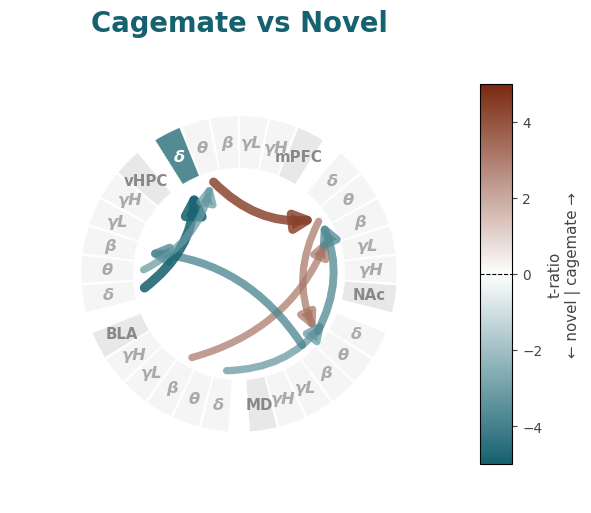

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.cm import ScalarMappable
import pandas as pd

# ── COLORS ────────────────────────────────────────────────────────────────────

agent_colors = {
    "cagemate": "#792910",
    "familiar": "#FFAF00",
    "novel":    "#15616F"
}

# ── LAYOUT ────────────────────────────────────────────────────────────────────

regions    = ["mPFC", "NAc", "MD", "BLA", "vHPC"]
bands      = ["Delta", "Theta", "Beta", "Low gamma", "High gamma"]
band_greek = ["δ", "θ", "β", "γL", "γH"]
FS         = 1.8

contrasts_to_plot = [
    #"cagemate - familiar",
    "cagemate - novel",
    #"familiar - novel"
]

contrast_labels = {
    #"cagemate - familiar": "Cagemate vs Familiar",
    "cagemate - novel":    "Cagemate vs Novel",
    #"familiar - novel":    "Familiar vs Novel"
}

contrast_colors = {
    #"cagemate - familiar": "#792910",
    "cagemate - novel":    "#15616F",
   # "familiar - novel":    "#FFAF00"
}

# ── LOAD DATA ─────────────────────────────────────────────────────────────────

power_emm           = pd.read_csv("pilot2/habit_dishabit_phase1/r_stuff/cage_v_nov_power_emm.csv")
coherence_emm       = pd.read_csv("pilot2/habit_dishabit_phase1/r_stuff/cage_v_nov_coherence_emm.csv")
granger_emm         = pd.read_csv("pilot2/habit_dishabit_phase1/r_stuff/cage_v_nov_granger_emm.csv")
power_contrasts     = pd.read_csv("pilot2/habit_dishabit_phase1/r_stuff/cage_v_nov_power_contrasts.csv")
coherence_contrasts = pd.read_csv("pilot2/habit_dishabit_phase1/r_stuff/cage_v_nov_coherence_contrasts.csv")
granger_contrasts   = pd.read_csv("pilot2/habit_dishabit_phase1/r_stuff/cage_v_nov_granger_contrasts.csv")

# ── FIX CAPITALIZATION ────────────────────────────────────────────────────────

name_fix = {"mPFC_Nac": "mPFC_NAc"}
coherence_emm["region"]       = coherence_emm["region"].replace(name_fix)
coherence_contrasts["region"] = coherence_contrasts["region"].replace(name_fix)
granger_contrasts["region"]   = granger_contrasts["region"].replace(name_fix)
granger_emm["region"]         = granger_emm["region"].replace(name_fix)

# ── SIGNIFICANT FILTER ────────────────────────────────────────────────────────

REAL_SIG = ["*", "**", "***"]

def is_real_sig(series):
    return series.notna() & series.isin(REAL_SIG)

sig_power = power_contrasts[is_real_sig(power_contrasts["sig"])].copy()

sig_power_main = (
    power_contrasts[
        is_real_sig(power_contrasts["sig"]) &
        power_contrasts["plot_type"].str.contains("main_effect", na=False)
    ]
    .drop_duplicates(subset=["region"])
    [["region"]]
    .copy()
)

sig_coherence_pairs = (
    coherence_contrasts[
        is_real_sig(coherence_contrasts["sig"]) &
        coherence_contrasts["band"].notna()
    ]
    .rename(columns={"region": "pair"})
    .drop_duplicates(subset=["pair", "band"])
    [["pair", "band"]]
    .copy()
)

sig_granger_pairs = (
    granger_contrasts[
        is_real_sig(granger_contrasts["sig"]) &
        granger_contrasts["band"].notna()
    ]
    .drop_duplicates(subset=["region", "band", "contrast"])
    [["region", "band", "contrast", "t.ratio"]]
    .copy()
)

valid_coherence_pairs = coherence_emm["region"].unique().tolist()

# ── GLOBAL T.RATIO RANGE ──────────────────────────────────────────────────────

all_t     = pd.concat([power_contrasts["t.ratio"].dropna(),
                       coherence_contrasts["t.ratio"].dropna()])
t_abs_max = np.ceil(all_t.abs().max())
norm      = Normalize(vmin=-t_abs_max, vmax=t_abs_max)

print(f"Global t.ratio range: ±{t_abs_max}")

# ── CONTRAST COLORMAPS ────────────────────────────────────────────────────────

def make_contrast_cmap(contrast_str):
    agents    = [a.strip() for a in contrast_str.split(" - ")]
    color_pos = mcolors.to_rgb(agent_colors[agents[0]])
    color_neg = mcolors.to_rgb(agent_colors[agents[1]])
    white     = (1.0, 1.0, 1.0)
    return LinearSegmentedColormap.from_list(
        f"cmap_{contrast_str}",
        [color_neg, white, color_pos]
    )

contrast_cmaps = {c: make_contrast_cmap(c) for c in contrasts_to_plot}

def t_to_color(t_ratio, contrast, alpha=1.0):
    rgba    = list(contrast_cmaps[contrast](norm(t_ratio)))
    rgba[3] = alpha
    return tuple(rgba)

# ── GEOMETRY ──────────────────────────────────────────────────────────────────

n_blocks        = len(bands) + 1                                          # 5 bands + 1 region block
region_span_deg = 65.0
gap_deg         = (360.0 - region_span_deg * len(regions)) / len(regions)
band_span_deg   = region_span_deg / n_blocks

region_center_angles = {}
start = 90.0
for i, r in enumerate(regions):
    region_center_angles[r] = start - i * (region_span_deg + gap_deg)

def band_center_deg(region, block_idx):
    rc    = region_center_angles[region]
    start = rc + region_span_deg / 2.0
    return start - (block_idx + 0.5) * band_span_deg

def region_block_center_deg(region):
    return band_center_deg(region, len(bands))   # last block

def deg2rad(d):
    return np.pi * d / 180.0

def arc_polygon(center_deg, half_deg, r_inner, r_outer, n=60):
    a0     = deg2rad(center_deg - half_deg)
    a1     = deg2rad(center_deg + half_deg)
    angles = np.linspace(a0, a1, n)
    xs     = np.concatenate([r_outer * np.cos(angles),
                              r_inner * np.cos(angles[::-1])])
    ys     = np.concatenate([r_outer * np.sin(angles),
                              r_inner * np.sin(angles[::-1])])
    return xs, ys

def chord_endpoint(region, block_idx, r=0.62):
    angle = deg2rad(band_center_deg(region, block_idx))
    return r * np.cos(angle), r * np.sin(angle)

def region_block_endpoint(region, r=0.62):
    angle = deg2rad(region_block_center_deg(region))
    return r * np.cos(angle), r * np.sin(angle)

def parse_pair(pair_name):
    if pair_name not in valid_coherence_pairs:
        return None, None
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

def parse_any_pair(pair_name):
    if "_to_" in pair_name:
        parts = pair_name.split("_to_")
        if len(parts) == 2 and parts[0] in regions and parts[1] in regions:
            return parts[0], parts[1]
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

def is_sig_power_cell(region, band, contrast):
    band_sig = (
        (sig_power["region"]   == region) &
        (sig_power["band"]     == band) &
        (sig_power["contrast"] == contrast)
    ).any()
    main_sig = (
        (sig_power_main["region"] == region).any() and
        (
            power_contrasts[
                (power_contrasts["region"]   == region) &
                (power_contrasts["contrast"] == contrast) &
                is_real_sig(power_contrasts["sig"])
            ].shape[0] > 0
        )
    )
    return bool(band_sig or main_sig)

# ── COHERENCE PLOT FUNCTION ───────────────────────────────────────────────────

def plot_connectogram(ax, cbar_ax, contrast, contrast_color, contrast_label):

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_title(contrast_label,
                 color=contrast_color, fontsize=11 * FS,
                 fontweight="bold", pad=10)

    r_inner = 0.67
    r_outer = 1.00
    half    = band_span_deg / 2.0 - 0.4

    # ── band blocks + region block ────────────────────────────────────────────
    for region in regions:

        # band blocks (0–4)
        for bi, (band, greek) in enumerate(zip(bands, band_greek)):
            center = band_center_deg(region, bi)
            is_sig = is_sig_power_cell(region, band, contrast)

            if is_sig:
                row = power_contrasts[
                    (power_contrasts["region"]   == region) &
                    (power_contrasts["band"]     == band) &
                    (power_contrasts["contrast"] == contrast)
                ]
                if len(row) == 0:
                    row = power_contrasts[
                        (power_contrasts["region"]   == region) &
                        (power_contrasts["contrast"] == contrast) &
                        is_real_sig(power_contrasts["sig"])
                    ]
                t_val = row["t.ratio"].values[0] if len(row) > 0 else 0.0
                color = t_to_color(t_val, contrast=contrast, alpha=0.9)
            else:
                color = (0.85, 0.85, 0.85, 0.25)

            xs, ys = arc_polygon(center, half, r_inner, r_outer)
            ax.fill(xs, ys, color=color, linewidth=0, zorder=2)
            ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                    color="white", lw=0.3, zorder=3)

            label_r = (r_inner + r_outer) / 2.0
            label_a = deg2rad(center)
            txt_col = "white" if is_sig else "#AAAAAA"
            ax.text(label_r * np.cos(label_a), label_r * np.sin(label_a),
                    greek,
                    ha="center", va="center",
                    fontsize=6.5 * FS, color=txt_col,
                    fontweight="bold", fontstyle="italic", zorder=4)

        # region block (index 5) — colored by main effect power
        center   = region_block_center_deg(region)
        main_row = power_contrasts[
            (power_contrasts["region"]   == region) &
            (power_contrasts["contrast"] == contrast) &
            power_contrasts["band"].isna() &
            is_real_sig(power_contrasts["sig"])
        ]
        if not main_row.empty:
            t_val       = main_row["t.ratio"].values[0]
            block_color = t_to_color(t_val, contrast=contrast, alpha=0.95)
            txt_col     = "white"
        else:
            block_color = (0.75, 0.75, 0.75, 0.35)
            txt_col     = "#888888"

        xs, ys = arc_polygon(center, half, r_inner, r_outer)
        ax.fill(xs, ys, color=block_color, linewidth=0, zorder=2)
        ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                color="white", lw=0.3, zorder=3)

        label_r = (r_inner + r_outer) / 2.0
        label_a = deg2rad(center)
        ax.text(label_r * np.cos(label_a), label_r * np.sin(label_a),
                region,
                ha="center", va="center",
                fontsize=6.0 * FS, color=txt_col,
                fontweight="bold", zorder=4)

    # ── band-level coherence chords ───────────────────────────────────────────
    plotted = set()
    for _, row in sig_coherence_pairs.iterrows():
        pair = row["pair"]
        band = row["band"]
        if band not in bands:
            continue
        bi     = bands.index(band)
        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue
        key = (pair, band)
        if key in plotted:
            continue
        plotted.add(key)

        coh_row = coherence_contrasts[
            (coherence_contrasts["region"].isin([pair, f"{r2}_{r1}"])) &
            (coherence_contrasts["band"]     == band) &
            (coherence_contrasts["contrast"] == contrast)
        ]
        if coh_row.empty:
            continue
        t_coh       = coh_row["t.ratio"].values[0]
        t_norm_mag  = min(abs(t_coh) / t_abs_max, 1.0)
        chord_color = t_to_color(t_coh, contrast=contrast,
                                 alpha=0.4 + 0.5 * t_norm_mag)
        x1, y1 = chord_endpoint(r1, bi)
        x2, y2 = chord_endpoint(r2, bi)

        ax.annotate("",
            xy=(x2, y2), xycoords="data",
            xytext=(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle="-", color=chord_color,
                lw=2 + 5 * t_norm_mag,
                connectionstyle="arc3,rad=0.25"
            ),
            zorder=1
        )

    # ── main effect coherence chords (region block → region block) ────────────
    sig_coh_main = (
        coherence_contrasts[
            is_real_sig(coherence_contrasts["sig"]) &
            coherence_contrasts["band"].isna() &
            (coherence_contrasts["contrast"] == contrast)
        ]
        .drop_duplicates(subset=["region"])
        [["region", "t.ratio"]]
        .copy()
    )
    for _, mrow in sig_coh_main.iterrows():
        pair   = mrow["region"]
        t      = mrow["t.ratio"]
        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue
        t_norm_mag  = min(abs(t) / t_abs_max, 1.0)
        chord_color = t_to_color(t, contrast=contrast,
                                 alpha=0.4 + 0.5 * t_norm_mag)
        x1, y1 = region_block_endpoint(r1)
        x2, y2 = region_block_endpoint(r2)

        ax.annotate("",
            xy=(x2, y2), xycoords="data",
            xytext=(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle="-", color=chord_color,
                lw=2 + 5 * t_norm_mag,
                connectionstyle="arc3,rad=0.3"
            ),
            zorder=1
        )

    # ── colorbar ──────────────────────────────────────────────────────────────
    sm = ScalarMappable(cmap=contrast_cmaps[contrast], norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cb.set_label(
        f"t-ratio\n← {contrast.split(' - ')[1]} | {contrast.split(' - ')[0]} →",
        fontsize=6 * FS, color="#444444"
    )
    cb.ax.tick_params(labelsize=5.5 * FS, colors="#444444")
    cb.ax.axhline(y=0, color="black", lw=0.8, linestyle="--")


# ── GRANGER PLOT FUNCTION ─────────────────────────────────────────────────────

def plot_granger_connectogram(ax, cbar_ax, contrast, contrast_color, contrast_label):

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_title(contrast_label,
                 color=contrast_color, fontsize=11 * FS,
                 fontweight="bold", pad=10)

    r_inner = 0.67
    r_outer = 1.00
    half    = band_span_deg / 2.0 - 0.4

    # ── band blocks + region block ────────────────────────────────────────────
    for region in regions:

        # band blocks (0–4)
        for bi, (band, greek) in enumerate(zip(bands, band_greek)):
            center = band_center_deg(region, bi)
            is_sig = is_sig_power_cell(region, band, contrast)

            if is_sig:
                row = power_contrasts[
                    (power_contrasts["region"]   == region) &
                    (power_contrasts["band"]     == band) &
                    (power_contrasts["contrast"] == contrast)
                ]
                if len(row) == 0:
                    row = power_contrasts[
                        (power_contrasts["region"]   == region) &
                        (power_contrasts["contrast"] == contrast) &
                        is_real_sig(power_contrasts["sig"])
                    ]
                t_val = row["t.ratio"].values[0] if len(row) > 0 else 0.0
                color = t_to_color(t_val, contrast=contrast, alpha=0.9)
            else:
                color = (0.85, 0.85, 0.85, 0.25)

            xs, ys = arc_polygon(center, half, r_inner, r_outer)
            ax.fill(xs, ys, color=color, linewidth=0, zorder=2)
            ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                    color="white", lw=0.3, zorder=3)

            label_r = (r_inner + r_outer) / 2.0
            label_a = deg2rad(center)
            txt_col = "white" if is_sig else "#AAAAAA"
            ax.text(label_r * np.cos(label_a), label_r * np.sin(label_a),
                    greek,
                    ha="center", va="center",
                    fontsize=6.5 * FS, color=txt_col,
                    fontweight="bold", fontstyle="italic", zorder=4)

        # region block (index 5) — colored by main effect power
        center   = region_block_center_deg(region)
        main_row = power_contrasts[
            (power_contrasts["region"]   == region) &
            (power_contrasts["contrast"] == contrast) &
            power_contrasts["band"].isna() &
            is_real_sig(power_contrasts["sig"])
        ]
        if not main_row.empty:
            t_val       = main_row["t.ratio"].values[0]
            block_color = t_to_color(t_val, contrast=contrast, alpha=0.95)
            txt_col     = "white"
        else:
            block_color = (0.75, 0.75, 0.75, 0.35)
            txt_col     = "#888888"

        xs, ys = arc_polygon(center, half, r_inner, r_outer)
        ax.fill(xs, ys, color=block_color, linewidth=0, zorder=2)
        ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                color="white", lw=0.3, zorder=3)

        label_r = (r_inner + r_outer) / 2.0
        label_a = deg2rad(center)
        ax.text(label_r * np.cos(label_a), label_r * np.sin(label_a),
                region,
                ha="center", va="center",
                fontsize=6.0 * FS, color=txt_col,
                fontweight="bold", zorder=4)

    # ── band-level granger arrows ─────────────────────────────────────────────
    gran_contrast = sig_granger_pairs[
        sig_granger_pairs["contrast"] == contrast
    ].copy()

    for _, row in gran_contrast.iterrows():
        pair = row["region"]
        band = row["band"]
        t    = row["t.ratio"]
        if band not in bands:
            continue
        bi     = bands.index(band)
        r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue

        t_norm_mag  = min(abs(t) / t_abs_max, 1.0)
        arrow_color = t_to_color(t, contrast=contrast,
                                 alpha=0.4 + 0.5 * t_norm_mag)
        x1, y1 = chord_endpoint(r1, bi)
        x2, y2 = chord_endpoint(r2, bi)

        ax.annotate("",
            xy=(x2, y2), xycoords="data",
            xytext=(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle="-|>",
                color=arrow_color,
                lw=2 + 5 * t_norm_mag,
                mutation_scale=12 + 18 * t_norm_mag,
                connectionstyle="arc3,rad=0.25"
            ),
            zorder=3
        )

    # ── main effect granger arrows (region block → region block) ─────────────
    gran_main = granger_contrasts[
        is_real_sig(granger_contrasts["sig"]) &
        granger_contrasts["band"].isna() &
        (granger_contrasts["contrast"] == contrast)
    ].copy()

    for _, mrow in gran_main.iterrows():
        pair   = mrow["region"]
        t      = mrow["t.ratio"]
        r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue

        t_norm_mag  = min(abs(t) / t_abs_max, 1.0)
        arrow_color = t_to_color(t, contrast=contrast,
                                 alpha=0.4 + 0.5 * t_norm_mag)
        x1, y1 = region_block_endpoint(r1)
        x2, y2 = region_block_endpoint(r2)

        ax.annotate("",
            xy=(x2, y2), xycoords="data",
            xytext=(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle="-|>",
                color=arrow_color,
                lw=2 + 5 * t_norm_mag,
                mutation_scale=12 + 18 * t_norm_mag,
                connectionstyle="arc3,rad=0.3"
            ),
            zorder=3
        )

    # ── colorbar ──────────────────────────────────────────────────────────────
    sm = ScalarMappable(cmap=contrast_cmaps[contrast], norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cb.set_label(
        f"t-ratio\n← {contrast.split(' - ')[1]} | {contrast.split(' - ')[0]} →",
        fontsize=6 * FS, color="#444444"
    )
    cb.ax.tick_params(labelsize=5.5 * FS, colors="#444444")
    cb.ax.axhline(y=0, color="black", lw=0.8, linestyle="--")


# ── RENDER BOTH FIGURES ───────────────────────────────────────────────────────

for plot_fn, fname, title in [
    (plot_connectogram,         "connectogram_coherence.png", "Coherence"),
    (plot_granger_connectogram, "connectogram_granger.png",   "Granger"),
]:
    fig      = plt.figure(figsize=(21, 8), facecolor="white")
    outer_gs = GridSpec(1, 3, wspace=0.12, figure=fig)

    for i, contrast in enumerate(contrasts_to_plot):
        inner_gs = GridSpecFromSubplotSpec(
            3, 2,
            subplot_spec  = outer_gs[i],
            width_ratios  = [1, 0.07],
            height_ratios = [0.15, 0.7, 0.15],
            wspace        = 0.05
        )
        ax      = fig.add_subplot(inner_gs[:, 0])
        cbar_ax = fig.add_subplot(inner_gs[1, 1])
        plot_fn(
            ax             = ax,
            cbar_ax        = cbar_ax,
            contrast       = contrast,
            contrast_color = contrast_colors[contrast],
            contrast_label = contrast_labels[contrast]
        )

    plt.savefig(fname, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

In [13]:
granger_contrasts[granger_contrasts['sig'].isin(REAL_SIG)]

,region,model_formula,plot_type,contrast,band,estimate,SE,df,t.ratio,p.value,p.value.adjusted,sig
1,mPFC_to_NAc,value ~ band * condition + velocity_mouse1 + (...,interaction,cagemate - novel,Theta,14.591487,3.315901,27.061027,4.400459,0.000152,0.004551,**
21,NAc_to_MD,value ~ band * condition + velocity_mouse1 + (...,interaction,cagemate - novel,Theta,8.270283,2.563749,84.198599,3.225855,0.001789,0.026839,*
32,BLA_to_NAc,value ~ band * condition + velocity_mouse1 + (...,interaction,cagemate - novel,Beta,8.529417,2.688910,61.243112,3.172072,0.002366,0.028393,*
35,BLA_to_MD,value ~ band * condition + velocity_mouse1 + (...,interaction,cagemate - novel,Delta,-12.062085,3.670443,17.411221,-3.286275,0.004249,0.035552,*
46,MD_to_NAc,value ~ band * condition + velocity_mouse1 + (...,interaction,cagemate - novel,Theta,-12.358116,3.350441,20.901002,-3.688504,0.001373,0.026839,*
52,MD_to_vHPC,value ~ band * condition + velocity_mouse1 + (...,interaction,cagemate - novel,Beta,-20.789630,5.537953,8.770032,-3.754028,0.004740,0.035552,*
55,vHPC_to_mPFC,value ~ band * condition + velocity_mouse1 + (...,interaction,cagemate - novel,Delta,-17.081307,3.518844,19.749242,-4.854238,0.000099,0.004551,**
56,vHPC_to_mPFC,value ~ band * condition + velocity_mouse1 + (...,interaction,cagemate - novel,Theta,-11.427289,3.518844,19.749242,-3.247455,0.004083,0.035552,*


Global t.ratio range: ±7.0


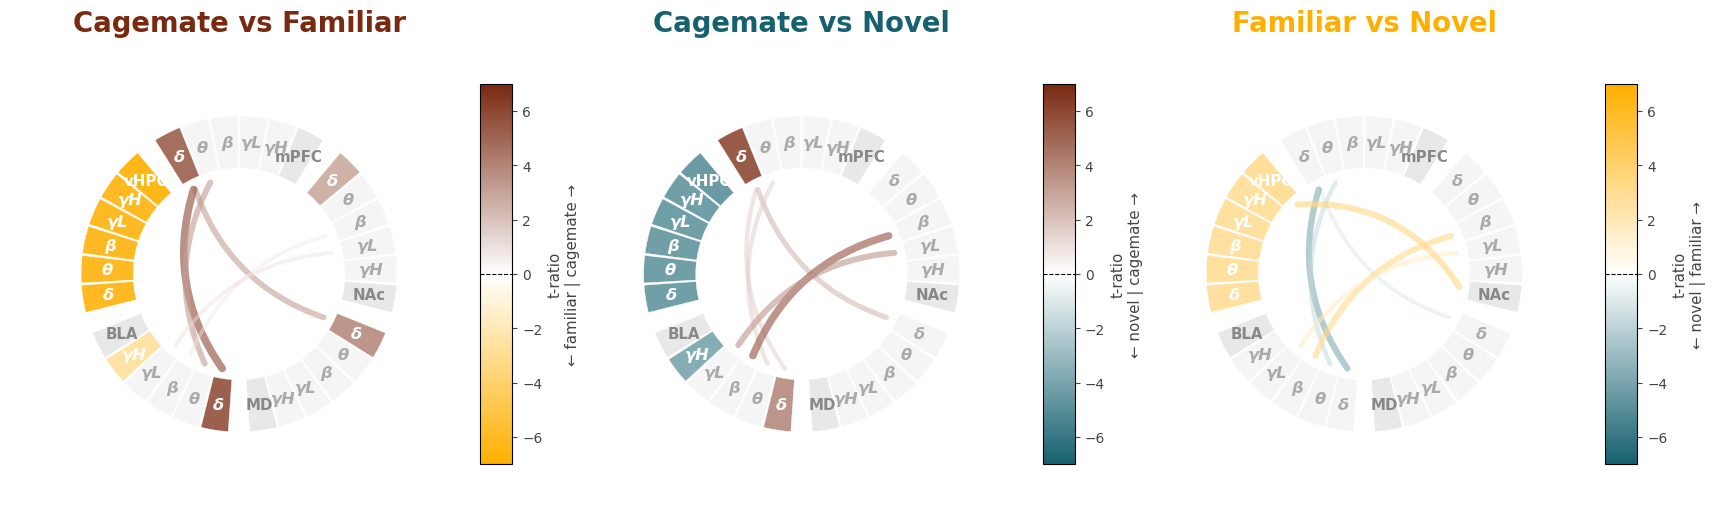

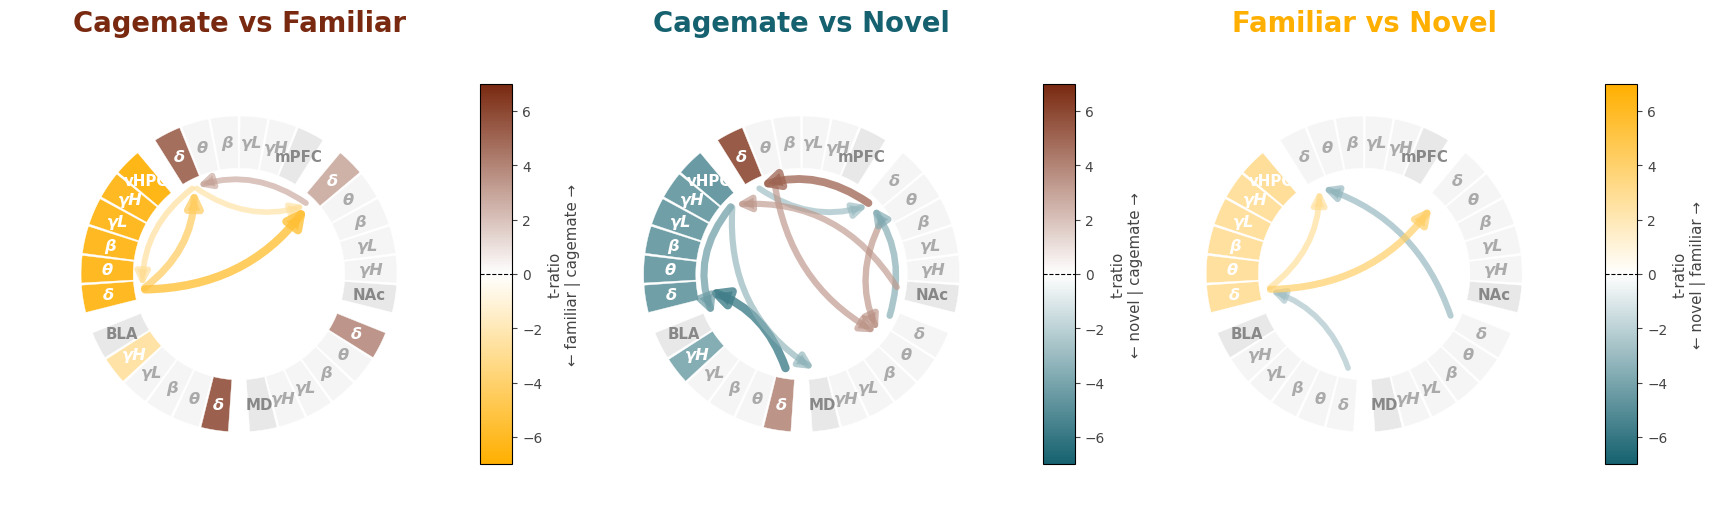

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.cm import ScalarMappable
import pandas as pd

# ── COLORS ────────────────────────────────────────────────────────────────────

agent_colors = {
    "cagemate": "#792910",
    "familiar": "#FFAF00",
    "novel":    "#15616F"
}

# ── LAYOUT ────────────────────────────────────────────────────────────────────

regions    = ["mPFC", "NAc", "MD", "BLA", "vHPC"]
bands      = ["Delta", "Theta", "Beta", "Low gamma", "High gamma"]
band_greek = ["δ", "θ", "β", "γL", "γH"]
FS         = 1.8

contrasts_to_plot = [
    "cagemate - familiar",
    "cagemate - novel",
    "familiar - novel"
]

contrast_labels = {
    "cagemate - familiar": "Cagemate vs Familiar",
    "cagemate - novel":    "Cagemate vs Novel",
    "familiar - novel":    "Familiar vs Novel"
}

contrast_colors = {
    "cagemate - familiar": "#792910",
    "cagemate - novel":    "#15616F",
    "familiar - novel":    "#FFAF00"
}

# ── LOAD DATA ─────────────────────────────────────────────────────────────────

power_emm           = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/power_emm.csv")
coherence_emm       = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/coherence_emm.csv")
granger_emm         = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/granger_emm.csv")
power_contrasts     = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/power_contrasts.csv")
coherence_contrasts = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/coherence_contrasts.csv")
granger_contrasts   = pd.read_csv("pilot2/cups_phase4/r_stuff/no_pref/granger_contrasts.csv")

# ── FIX CAPITALIZATION ────────────────────────────────────────────────────────

name_fix = {"mPFC_Nac": "mPFC_NAc"}
coherence_emm["region"]       = coherence_emm["region"].replace(name_fix)
coherence_contrasts["region"] = coherence_contrasts["region"].replace(name_fix)
granger_contrasts["region"]   = granger_contrasts["region"].replace(name_fix)
granger_emm["region"]         = granger_emm["region"].replace(name_fix)

# ── SIGNIFICANT FILTER ────────────────────────────────────────────────────────

REAL_SIG = ["*", "**", "***"]

def is_real_sig(series):
    return series.notna() & series.isin(REAL_SIG)

sig_power = power_contrasts[is_real_sig(power_contrasts["sig"])].copy()

sig_power_main = (
    power_contrasts[
        is_real_sig(power_contrasts["sig"]) &
        power_contrasts["plot_type"].str.contains("main_effect", na=False)
    ]
    .drop_duplicates(subset=["region"])
    [["region"]]
    .copy()
)

sig_coherence_pairs = (
    coherence_contrasts[
        is_real_sig(coherence_contrasts["sig"]) &
        coherence_contrasts["band"].notna()
    ]
    .rename(columns={"region": "pair"})
    .drop_duplicates(subset=["pair", "band"])
    [["pair", "band"]]
    .copy()
)

sig_granger_pairs = (
    granger_contrasts[
        is_real_sig(granger_contrasts["sig"]) &
        granger_contrasts["band"].notna()
    ]
    .drop_duplicates(subset=["region", "band", "contrast"])
    [["region", "band", "contrast", "t.ratio"]]
    .copy()
)

valid_coherence_pairs = coherence_emm["region"].unique().tolist()

# ── GLOBAL T.RATIO RANGE ──────────────────────────────────────────────────────

all_t     = pd.concat([power_contrasts["t.ratio"].dropna(),
                       coherence_contrasts["t.ratio"].dropna()])
t_abs_max = np.ceil(all_t.abs().max())
norm      = Normalize(vmin=-t_abs_max, vmax=t_abs_max)

print(f"Global t.ratio range: ±{t_abs_max}")

# ── CONTRAST COLORMAPS ────────────────────────────────────────────────────────

def make_contrast_cmap(contrast_str):
    agents    = [a.strip() for a in contrast_str.split(" - ")]
    color_pos = mcolors.to_rgb(agent_colors[agents[0]])
    color_neg = mcolors.to_rgb(agent_colors[agents[1]])
    white     = (1.0, 1.0, 1.0)
    return LinearSegmentedColormap.from_list(
        f"cmap_{contrast_str}",
        [color_neg, white, color_pos]
    )

contrast_cmaps = {c: make_contrast_cmap(c) for c in contrasts_to_plot}

def t_to_color(t_ratio, contrast, alpha=1.0):
    rgba    = list(contrast_cmaps[contrast](norm(t_ratio)))
    rgba[3] = alpha
    return tuple(rgba)

# ── GEOMETRY ──────────────────────────────────────────────────────────────────

n_blocks        = len(bands) + 1                                          # 5 bands + 1 region block
region_span_deg = 65.0
gap_deg         = (360.0 - region_span_deg * len(regions)) / len(regions)
band_span_deg   = region_span_deg / n_blocks

region_center_angles = {}
start = 90.0
for i, r in enumerate(regions):
    region_center_angles[r] = start - i * (region_span_deg + gap_deg)

def band_center_deg(region, block_idx):
    rc    = region_center_angles[region]
    start = rc + region_span_deg / 2.0
    return start - (block_idx + 0.5) * band_span_deg

def region_block_center_deg(region):
    return band_center_deg(region, len(bands))   # last block

def deg2rad(d):
    return np.pi * d / 180.0

def arc_polygon(center_deg, half_deg, r_inner, r_outer, n=60):
    a0     = deg2rad(center_deg - half_deg)
    a1     = deg2rad(center_deg + half_deg)
    angles = np.linspace(a0, a1, n)
    xs     = np.concatenate([r_outer * np.cos(angles),
                              r_inner * np.cos(angles[::-1])])
    ys     = np.concatenate([r_outer * np.sin(angles),
                              r_inner * np.sin(angles[::-1])])
    return xs, ys

def chord_endpoint(region, block_idx, r=0.62):
    angle = deg2rad(band_center_deg(region, block_idx))
    return r * np.cos(angle), r * np.sin(angle)

def region_block_endpoint(region, r=0.62):
    angle = deg2rad(region_block_center_deg(region))
    return r * np.cos(angle), r * np.sin(angle)

def parse_pair(pair_name):
    if pair_name not in valid_coherence_pairs:
        return None, None
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

def parse_any_pair(pair_name):
    if "_to_" in pair_name:
        parts = pair_name.split("_to_")
        if len(parts) == 2 and parts[0] in regions and parts[1] in regions:
            return parts[0], parts[1]
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

def is_sig_power_cell(region, band, contrast):
    band_sig = (
        (sig_power["region"]   == region) &
        (sig_power["band"]     == band) &
        (sig_power["contrast"] == contrast)
    ).any()
    main_sig = (
        (sig_power_main["region"] == region).any() and
        (
            power_contrasts[
                (power_contrasts["region"]   == region) &
                (power_contrasts["contrast"] == contrast) &
                is_real_sig(power_contrasts["sig"])
            ].shape[0] > 0
        )
    )
    return bool(band_sig or main_sig)

# ── COHERENCE PLOT FUNCTION ───────────────────────────────────────────────────

def plot_connectogram(ax, cbar_ax, contrast, contrast_color, contrast_label):

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_title(contrast_label,
                 color=contrast_color, fontsize=11 * FS,
                 fontweight="bold", pad=10)

    r_inner = 0.67
    r_outer = 1.00
    half    = band_span_deg / 2.0 - 0.4

    # ── band blocks + region block ────────────────────────────────────────────
    for region in regions:

        # band blocks (0–4)
        for bi, (band, greek) in enumerate(zip(bands, band_greek)):
            center = band_center_deg(region, bi)
            is_sig = is_sig_power_cell(region, band, contrast)

            if is_sig:
                row = power_contrasts[
                    (power_contrasts["region"]   == region) &
                    (power_contrasts["band"]     == band) &
                    (power_contrasts["contrast"] == contrast)
                ]
                if len(row) == 0:
                    row = power_contrasts[
                        (power_contrasts["region"]   == region) &
                        (power_contrasts["contrast"] == contrast) &
                        is_real_sig(power_contrasts["sig"])
                    ]
                t_val = row["t.ratio"].values[0] if len(row) > 0 else 0.0
                color = t_to_color(t_val, contrast=contrast, alpha=0.9)
            else:
                color = (0.85, 0.85, 0.85, 0.25)

            xs, ys = arc_polygon(center, half, r_inner, r_outer)
            ax.fill(xs, ys, color=color, linewidth=0, zorder=2)
            ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                    color="white", lw=0.3, zorder=3)

            label_r = (r_inner + r_outer) / 2.0
            label_a = deg2rad(center)
            txt_col = "white" if is_sig else "#AAAAAA"
            ax.text(label_r * np.cos(label_a), label_r * np.sin(label_a),
                    greek,
                    ha="center", va="center",
                    fontsize=6.5 * FS, color=txt_col,
                    fontweight="bold", fontstyle="italic", zorder=4)

        # region block (index 5) — colored by main effect power
        center   = region_block_center_deg(region)
        main_row = power_contrasts[
            (power_contrasts["region"]   == region) &
            (power_contrasts["contrast"] == contrast) &
            power_contrasts["band"].isna() &
            is_real_sig(power_contrasts["sig"])
        ]
        if not main_row.empty:
            t_val       = main_row["t.ratio"].values[0]
            block_color = t_to_color(t_val, contrast=contrast, alpha=0.95)
            txt_col     = "white"
        else:
            block_color = (0.75, 0.75, 0.75, 0.35)
            txt_col     = "#888888"

        xs, ys = arc_polygon(center, half, r_inner, r_outer)
        ax.fill(xs, ys, color=block_color, linewidth=0, zorder=2)
        ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                color="white", lw=0.3, zorder=3)

        label_r = (r_inner + r_outer) / 2.0
        label_a = deg2rad(center)
        ax.text(label_r * np.cos(label_a), label_r * np.sin(label_a),
                region,
                ha="center", va="center",
                fontsize=6.0 * FS, color=txt_col,
                fontweight="bold", zorder=4)

    # ── band-level coherence chords ───────────────────────────────────────────
    plotted = set()
    for _, row in sig_coherence_pairs.iterrows():
        pair = row["pair"]
        band = row["band"]
        if band not in bands:
            continue
        bi     = bands.index(band)
        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue
        key = (pair, band)
        if key in plotted:
            continue
        plotted.add(key)

        coh_row = coherence_contrasts[
            (coherence_contrasts["region"].isin([pair, f"{r2}_{r1}"])) &
            (coherence_contrasts["band"]     == band) &
            (coherence_contrasts["contrast"] == contrast)
        ]
        if coh_row.empty:
            continue
        t_coh       = coh_row["t.ratio"].values[0]
        t_norm_mag  = min(abs(t_coh) / t_abs_max, 1.0)
        chord_color = t_to_color(t_coh, contrast=contrast,
                                 alpha=0.4 + 0.5 * t_norm_mag)
        x1, y1 = chord_endpoint(r1, bi)
        x2, y2 = chord_endpoint(r2, bi)

        ax.annotate("",
            xy=(x2, y2), xycoords="data",
            xytext=(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle="-", color=chord_color,
                lw=2 + 5 * t_norm_mag,
                connectionstyle="arc3,rad=0.25"
            ),
            zorder=1
        )

    # ── main effect coherence chords (region block → region block) ────────────
    sig_coh_main = (
        coherence_contrasts[
            is_real_sig(coherence_contrasts["sig"]) &
            coherence_contrasts["band"].isna() &
            (coherence_contrasts["contrast"] == contrast)
        ]
        .drop_duplicates(subset=["region"])
        [["region", "t.ratio"]]
        .copy()
    )
    for _, mrow in sig_coh_main.iterrows():
        pair   = mrow["region"]
        t      = mrow["t.ratio"]
        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue
        t_norm_mag  = min(abs(t) / t_abs_max, 1.0)
        chord_color = t_to_color(t, contrast=contrast,
                                 alpha=0.4 + 0.5 * t_norm_mag)
        x1, y1 = region_block_endpoint(r1)
        x2, y2 = region_block_endpoint(r2)

        ax.annotate("",
            xy=(x2, y2), xycoords="data",
            xytext=(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle="-", color=chord_color,
                lw=2 + 5 * t_norm_mag,
                connectionstyle="arc3,rad=0.3"
            ),
            zorder=1
        )

    # ── colorbar ──────────────────────────────────────────────────────────────
    sm = ScalarMappable(cmap=contrast_cmaps[contrast], norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cb.set_label(
        f"t-ratio\n← {contrast.split(' - ')[1]} | {contrast.split(' - ')[0]} →",
        fontsize=6 * FS, color="#444444"
    )
    cb.ax.tick_params(labelsize=5.5 * FS, colors="#444444")
    cb.ax.axhline(y=0, color="black", lw=0.8, linestyle="--")


# ── GRANGER PLOT FUNCTION ─────────────────────────────────────────────────────

def plot_granger_connectogram(ax, cbar_ax, contrast, contrast_color, contrast_label):

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_title(contrast_label,
                 color=contrast_color, fontsize=11 * FS,
                 fontweight="bold", pad=10)

    r_inner = 0.67
    r_outer = 1.00
    half    = band_span_deg / 2.0 - 0.4

    # ── band blocks + region block ────────────────────────────────────────────
    for region in regions:

        # band blocks (0–4)
        for bi, (band, greek) in enumerate(zip(bands, band_greek)):
            center = band_center_deg(region, bi)
            is_sig = is_sig_power_cell(region, band, contrast)

            if is_sig:
                row = power_contrasts[
                    (power_contrasts["region"]   == region) &
                    (power_contrasts["band"]     == band) &
                    (power_contrasts["contrast"] == contrast)
                ]
                if len(row) == 0:
                    row = power_contrasts[
                        (power_contrasts["region"]   == region) &
                        (power_contrasts["contrast"] == contrast) &
                        is_real_sig(power_contrasts["sig"])
                    ]
                t_val = row["t.ratio"].values[0] if len(row) > 0 else 0.0
                color = t_to_color(t_val, contrast=contrast, alpha=0.9)
            else:
                color = (0.85, 0.85, 0.85, 0.25)

            xs, ys = arc_polygon(center, half, r_inner, r_outer)
            ax.fill(xs, ys, color=color, linewidth=0, zorder=2)
            ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                    color="white", lw=0.3, zorder=3)

            label_r = (r_inner + r_outer) / 2.0
            label_a = deg2rad(center)
            txt_col = "white" if is_sig else "#AAAAAA"
            ax.text(label_r * np.cos(label_a), label_r * np.sin(label_a),
                    greek,
                    ha="center", va="center",
                    fontsize=6.5 * FS, color=txt_col,
                    fontweight="bold", fontstyle="italic", zorder=4)

        # region block (index 5) — colored by main effect power
        center   = region_block_center_deg(region)
        main_row = power_contrasts[
            (power_contrasts["region"]   == region) &
            (power_contrasts["contrast"] == contrast) &
            power_contrasts["band"].isna() &
            is_real_sig(power_contrasts["sig"])
        ]
        if not main_row.empty:
            t_val       = main_row["t.ratio"].values[0]
            block_color = t_to_color(t_val, contrast=contrast, alpha=0.95)
            txt_col     = "white"
        else:
            block_color = (0.75, 0.75, 0.75, 0.35)
            txt_col     = "#888888"

        xs, ys = arc_polygon(center, half, r_inner, r_outer)
        ax.fill(xs, ys, color=block_color, linewidth=0, zorder=2)
        ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                color="white", lw=0.3, zorder=3)

        label_r = (r_inner + r_outer) / 2.0
        label_a = deg2rad(center)
        ax.text(label_r * np.cos(label_a), label_r * np.sin(label_a),
                region,
                ha="center", va="center",
                fontsize=6.0 * FS, color=txt_col,
                fontweight="bold", zorder=4)

    # ── band-level granger arrows ─────────────────────────────────────────────
    gran_contrast = sig_granger_pairs[
        sig_granger_pairs["contrast"] == contrast
    ].copy()

    for _, row in gran_contrast.iterrows():
        pair = row["region"]
        band = row["band"]
        t    = row["t.ratio"]
        if band not in bands:
            continue
        bi     = bands.index(band)
        r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue

        t_norm_mag  = min(abs(t) / t_abs_max, 1.0)
        arrow_color = t_to_color(t, contrast=contrast,
                                 alpha=0.4 + 0.5 * t_norm_mag)
        x1, y1 = chord_endpoint(r1, bi)
        x2, y2 = chord_endpoint(r2, bi)

        ax.annotate("",
            xy=(x2, y2), xycoords="data",
            xytext=(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle="-|>",
                color=arrow_color,
                lw=2 + 5 * t_norm_mag,
                mutation_scale=12 + 18 * t_norm_mag,
                connectionstyle="arc3,rad=0.25"
            ),
            zorder=3
        )

    # ── main effect granger arrows (region block → region block) ─────────────
    gran_main = granger_contrasts[
        is_real_sig(granger_contrasts["sig"]) &
        granger_contrasts["band"].isna() &
        (granger_contrasts["contrast"] == contrast)
    ].copy()

    for _, mrow in gran_main.iterrows():
        pair   = mrow["region"]
        t      = mrow["t.ratio"]
        r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue

        t_norm_mag  = min(abs(t) / t_abs_max, 1.0)
        arrow_color = t_to_color(t, contrast=contrast,
                                 alpha=0.4 + 0.5 * t_norm_mag)
        x1, y1 = region_block_endpoint(r1)
        x2, y2 = region_block_endpoint(r2)

        ax.annotate("",
            xy=(x2, y2), xycoords="data",
            xytext=(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle="-|>",
                color=arrow_color,
                lw=2 + 5 * t_norm_mag,
                mutation_scale=12 + 18 * t_norm_mag,
                connectionstyle="arc3,rad=0.3"
            ),
            zorder=3
        )

    # ── colorbar ──────────────────────────────────────────────────────────────
    sm = ScalarMappable(cmap=contrast_cmaps[contrast], norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cb.set_label(
        f"t-ratio\n← {contrast.split(' - ')[1]} | {contrast.split(' - ')[0]} →",
        fontsize=6 * FS, color="#444444"
    )
    cb.ax.tick_params(labelsize=5.5 * FS, colors="#444444")
    cb.ax.axhline(y=0, color="black", lw=0.8, linestyle="--")


# ── RENDER BOTH FIGURES ───────────────────────────────────────────────────────

for plot_fn, fname, title in [
    (plot_connectogram,         "connectogram_coherence.png", "Coherence"),
    (plot_granger_connectogram, "connectogram_granger.png",   "Granger"),
]:
    fig      = plt.figure(figsize=(21, 8), facecolor="white")
    outer_gs = GridSpec(1, 3, wspace=0.12, figure=fig)

    for i, contrast in enumerate(contrasts_to_plot):
        inner_gs = GridSpecFromSubplotSpec(
            3, 2,
            subplot_spec  = outer_gs[i],
            width_ratios  = [1, 0.07],
            height_ratios = [0.15, 0.7, 0.15],
            wspace        = 0.05
        )
        ax      = fig.add_subplot(inner_gs[:, 0])
        cbar_ax = fig.add_subplot(inner_gs[1, 1])
        plot_fn(
            ax             = ax,
            cbar_ax        = cbar_ax,
            contrast       = contrast,
            contrast_color = contrast_colors[contrast],
            contrast_label = contrast_labels[contrast]
        )

    plt.savefig(fname, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

In [ ]:
granger_contrasts

,region,model_formula,plot_type,contrast,band,estimate,SE,df,t.ratio,p.value,p.value.adjusted,sig
0,mPFC_to_NAc,value ~ band * agent + (1 | X),interaction,cagemate - familiar,Delta,-11.085082,3.945071,2593.544795,-2.809857,0.004994,0.044942,*
1,mPFC_to_NAc,value ~ band * agent + (1 | X),interaction,cagemate - novel,Delta,-9.811026,3.099735,2487.003256,-3.165118,0.001569,0.019551,*
2,mPFC_to_NAc,value ~ band * agent + (1 | X),interaction,familiar - novel,Delta,1.274056,3.989138,2601.782496,0.319381,0.749463,0.870580,NaN
3,mPFC_to_NAc,value ~ band * agent + (1 | X),interaction,cagemate - familiar,Theta,-2.261388,3.945071,2593.544795,-0.573219,0.566546,0.820193,NaN
4,mPFC_to_NAc,value ~ band * agent + (1 | X),interaction,cagemate - novel,Theta,2.330731,3.099735,2487.003256,0.751913,0.452175,0.711187,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
157,vHPC_to_BLA,value ~ band * agent + (1 | X),main_effect,cagemate - novel,NaN,-8.063954,1.834588,1274.959944,-4.395513,0.000012,0.000388,***
158,vHPC_to_BLA,value ~ band * agent + (1 | X),main_effect,familiar - novel,NaN,-2.705067,2.584561,1274.337159,-1.046625,0.295471,0.568165,NaN
159,vHPC_to_MD,value ~ band * agent + (1 | X),main_effect,cagemate - familiar,NaN,-2.714154,2.046189,1514.988416,-1.326443,0.184893,0.496122,NaN
160,vHPC_to_MD,value ~ band * agent + (1 | X),main_effect,cagemate - novel,NaN,-5.520128,1.612641,1514.178615,-3.423036,0.000636,0.009363,**
